The following notebook has demo cells for each of the following functionalities:

1. **Global partition** image with nodes **colored by rank** (full node names)
2. **Per-rank views** — one image per rank
3. **No coloring / no inter-rank highlight** for comparison
4. **Saving** the graph as a **pickle**
5. **Saving** the graph as **GraphML**
6. **Reloading** the saved graphs and rendering images from them
7. Rendering with the **DOT backend** (global and per-rank)
8. Converting **DOT files to NetworkX** images (combined)
9. Converting **DOT files to NetworkX** images (per-rank, left separate)
10. **Hierarchy view** showing only the links between SubGrids
11. **AHP's simple HPC example** — a non-grid graph rendered with the same API

The grid layout and compact `row,col` labels are no longer hard-coded inside
`ahp_graph`. They are supplied by the PHOLD example as `layout` / `node_label`
**callbacks** (see the "Grid layout & label callbacks" section), so the library
stays domain-agnostic and works for arbitrary graphs like the HPC example.

All artifacts are written to the local `output/` directory.


## Imports and ahp_graph path setup

If `AHP_PATH` is not set, we fall back to the sibling `ahp_graph/src` checkout
in this workspace.

In [1]:
import os
import sys

sys.path.append(os.environ.get('AHP_PATH', '.'))
# Fall back to the sibling ahp_graph/src checkout in this workspace.
_repo_ahp_src = os.path.abspath(os.path.join('..', '..', '..', 'ahp_graph', 'src'))
if os.path.isdir(_repo_ahp_src):
    sys.path.append(_repo_ahp_src)

_ENV_HELP = (
    "Could not import the visualization stack. This kernel must be started "
    "from a shell that has sourced the SST environment so graphviz is on "
    "LD_LIBRARY_PATH:\n"
    "    source setSSTEnvironment.sh source\n"
    "then launch Jupyter/VS Code and select that interpreter as the kernel. "
    "LD_LIBRARY_PATH is read at process launch, so it cannot be fixed from "
    "inside a running kernel."
)

try:
    from ahp_graph.Device import Device, PortInfo
    from ahp_graph.DeviceGraph import DeviceGraph
    from IPython.display import Image, SVG, display
except ImportError as exc:
    raise ImportError(f"{_ENV_HELP}\n\nOriginal error: {exc}") from exc

print("Environment OK: ahp_graph and visualization dependencies imported.")

Environment OK: ahp_graph and visualization dependencies imported.


## Configuration

These values replace the command-line arguments of `visualize_phold.py`.
Edit them and re-run the notebook to explore different grid sizes, ring
radii, and rank counts.

In [2]:
import types

# A lightweight stand-in for the argparse namespace so the PHOLD device
# code can be reused unchanged.
args = types.SimpleNamespace(
    height=4,
    width=4,
    linkDelay='1ns',
    numRings=1,
    nodeType='phold.Node',
    no_self_links=False,
    verbose=0,
    print_links=False,
    num_ranks=2,
    rank=0,
    architecture='global',
)

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_RINGS = args.numRings
SIDE = NUM_RINGS * 2 + 1
MAX_SIZE = SIDE * SIDE

## Port and index helpers

These map grid offsets to unique multi-port indices, exactly as in
`phold_dist_ahp.py`.

In [3]:
def port_num(src_i, src_j, dst_i, dst_j):
    '''Return port index for link from (src_i,src_j) to (dst_i,dst_j).'''
    side_length = NUM_RINGS * 2 + 1
    di = src_i - dst_i
    dj = src_j - dst_j
    ip = NUM_RINGS - di
    jp = NUM_RINGS - dj
    return ip * side_length + jp


def border_index(col_j, dj, src_row_offset, tgt_row_offset):
    '''Compute the global multi-port index for a border link.'''
    base = col_j * NUM_RINGS * NUM_RINGS * SIDE
    dj_idx = dj + NUM_RINGS  # Convert dj from [-R, R] to [0, 2R]
    return base + src_row_offset * NUM_RINGS * SIDE + tgt_row_offset * SIDE + dj_idx


def log_link(msg, level=1):
    '''Log link wiring if verbosity is sufficient or print-links is set.'''
    if args.print_links or args.verbose >= level:
        print(msg)

## Device definitions

`Node` is a single PHOLD grid cell; `SubGrid` is a row-partitioned assembly
that wires internal links and anchors border links. These are copied from
`phold_dist_ahp.py`.

In [4]:
class Node(Device):
    '''PHOLD node device: exposes ports to neighbors within R rings.'''
    library = args.nodeType

    def __init__(self, name, i, j):
        super().__init__(name)
        self.type = None
        self.portinfo = PortInfo()

        # Iterate neighbor offsets within ring radius; include self (0,0).
        for di in range(-NUM_RINGS, NUM_RINGS + 1):
            for dj in range(-NUM_RINGS, NUM_RINGS + 1):
                if (1 <= max(abs(di), abs(dj)) <= NUM_RINGS or (di == 0 and dj == 0)):
                    dst_i = i + di
                    dst_j = j + dj
                    if 0 <= dst_i < args.height and 0 <= dst_j < args.width:
                        pnum = port_num(i, j, dst_i, dst_j)
                        self.portinfo.add(f'port{pnum}', 'String', required=False)

        self.attr = {'i': i, 'j': j, 'numRings': NUM_RINGS}


class SubGrid(Device):
    '''Row-partitioned assembly; wires internal links and border anchors.'''

    portinfo = PortInfo()
    portinfo.add('northBorder', 'String',
                 limit=args.width * NUM_RINGS * NUM_RINGS * SIDE, required=False)
    portinfo.add('southBorder', 'String',
                 limit=args.width * NUM_RINGS * NUM_RINGS * SIDE, required=False)

    def __init__(self, name, row_start, row_end):
        super().__init__(name)
        self.row_start = row_start
        self.row_end = row_end
        self.nodes = {}

    def expand(self, graph):
        self.nodes = {}
        for i in range(self.row_start, self.row_end):
            self.nodes[i] = {}
            for j in range(args.width):
                n = Node(f'comp_{i}_{j}', i, j)
                if getattr(self, 'partition', None) is not None:
                    n.set_partition(self.partition[0], self.partition[1])
                self.nodes[i][j] = n

        M = args.width

        # Internal links (with a duplicate-avoid rule) and self-links.
        for i in range(self.row_start, self.row_end):
            for j in range(M):
                for di in range(-NUM_RINGS, NUM_RINGS + 1):
                    for dj in range(-NUM_RINGS, NUM_RINGS + 1):
                        if max(abs(di), abs(dj)) > NUM_RINGS:
                            continue
                        ni = i + di
                        nj = j + dj
                        if not (0 <= ni < args.height and 0 <= nj < M):
                            continue
                        src_idx = port_num(i, j, ni, nj)
                        tgt_idx = port_num(ni, nj, i, j)
                        src_port = f'port{src_idx}'
                        tgt_port = f'port{tgt_idx}'
                        if self.row_start <= ni < self.row_end:
                            if di == 0 and dj == 0:
                                if args.no_self_links:
                                    continue
                            else:
                                if not (di < 0 or (di == 0 and dj < 0)):
                                    continue
                            src_node = self.nodes[i][j]
                            tgt_node = self.nodes[ni][nj]
                            graph.link(getattr(src_node, src_port),
                                       getattr(tgt_node, tgt_port), args.linkDelay)
                        elif 0 <= ni < args.height:
                            continue

        # Single-link border sweeps: one anchor per border index.
        tops = list(range(self.row_start, min(self.row_start + NUM_RINGS, self.row_end)))
        bots = list(range(max(self.row_start, self.row_end - NUM_RINGS), self.row_end))

        # North border sweep: connect to neighbors above this subgrid.
        for i in tops:
            for j in range(args.width):
                for di in range(-NUM_RINGS, 0):
                    for dj in range(-NUM_RINGS, NUM_RINGS + 1):
                        if max(abs(di), abs(dj)) > NUM_RINGS:
                            continue
                        ni = i + di
                        nj = j + dj
                        if ni < self.row_start and 0 <= nj < args.width and 0 <= ni:
                            upper_row_end = self.row_start
                            src_row_offset = (upper_row_end - 1) - ni
                            tgt_row_offset = i - upper_row_end
                            bidx = border_index(nj, -dj, src_row_offset, tgt_row_offset)
                            nb = self.northBorder(bidx)
                            src_idx = port_num(i, j, ni, nj)
                            graph.link(getattr(self.nodes[i][j], f'port{src_idx}'),
                                       nb, args.linkDelay)

        # South border sweep: connect to neighbors below this subgrid.
        for i in bots:
            for j in range(args.width):
                for di in range(1, NUM_RINGS + 1):
                    for dj in range(-NUM_RINGS, NUM_RINGS + 1):
                        if max(di, abs(dj)) > NUM_RINGS:
                            continue
                        ni = i + di
                        nj = j + dj
                        if ni >= self.row_end and 0 <= nj < args.width and ni < args.height:
                            src_row_offset = (self.row_end - 1) - i
                            tgt_row_offset = ni - self.row_end
                            bidx = border_index(j, dj, src_row_offset, tgt_row_offset)
                            sb = self.southBorder(bidx)
                            src_idx = port_num(i, j, ni, nj)
                            graph.link(getattr(self.nodes[i][j], f'port{src_idx}'),
                                       sb, args.linkDelay)

## Architecture builders

`architecture_global` builds every partition (best for a colored,
whole-topology image), while `architecture_spmd` only builds partitions near
`args.rank`. The `make_graph` helper builds and fully flattens a fresh graph
so the individual `comp` nodes (each carrying their rank) are visible.

In [5]:
def _connect_borders(graph, upper, lower):
    '''Wire the border links between two vertically adjacent subgrids.'''
    for src_row_offset in range(NUM_RINGS):
        for tgt_row_offset in range(NUM_RINGS):
            total_di = src_row_offset + 1 + tgt_row_offset
            if total_di > NUM_RINGS:
                continue
            for j in range(args.width):
                for dj in range(-NUM_RINGS, NUM_RINGS + 1):
                    if max(total_di, abs(dj)) > NUM_RINGS:
                        continue
                    jj = j + dj
                    if not (0 <= jj < args.width):
                        continue
                    bidx = border_index(j, dj, src_row_offset, tgt_row_offset)
                    graph.link(upper.southBorder(bidx),
                               lower.northBorder(bidx), args.linkDelay)


def architecture_spmd(num_boards):
    '''Build a row-partitioned device graph, only near args.rank.'''
    graph = DeviceGraph()
    subgrids = {}
    my_rank = args.rank
    rows_per = args.height // num_boards if num_boards > 0 else args.height
    start_idx = max(0, my_rank - 1)
    end_idx = min(num_boards, my_rank + 2)
    for i in range(start_idx, end_idx):
        row_start = i * rows_per
        row_end = (i + 1) * rows_per if i != num_boards - 1 else args.height
        sub = SubGrid(f'SubGrid{i}', row_start, row_end)
        sub.set_partition(i)
        graph.add(sub)
        subgrids[i] = sub
    for i in range(max(1, my_rank), min(num_boards, my_rank + 2)):
        if (i - 1) in subgrids and i in subgrids:
            _connect_borders(graph, subgrids[i - 1], subgrids[i])
    return graph


def architecture_global(num_boards):
    '''Build a row-partitioned device graph with every partition present.'''
    graph = DeviceGraph()
    subgrids = {}
    rows_per = args.height // num_boards if num_boards > 0 else args.height
    for i in range(num_boards):
        row_start = i * rows_per
        row_end = (i + 1) * rows_per if i != num_boards - 1 else args.height
        sub = SubGrid(f'SubGrid{i}', row_start, row_end)
        sub.set_partition(i)
        graph.add(sub)
        subgrids[i] = sub
    for i in range(1, num_boards):
        _connect_borders(graph, subgrids[i - 1], subgrids[i])
    return graph


def make_graph():
    '''Build and fully flatten a fresh PHOLD graph using the current config.'''
    if args.architecture.lower() == 'spmd':
        graph = architecture_spmd(args.num_ranks)
    else:
        graph = architecture_global(args.num_ranks)
    graph.flatten()
    return graph


def make_rank_graph(r):
    '''Build a per-rank view of the topology.

    Builds every partition, flattens the assembly on rank r, then follows and
    prunes links so the result holds rank r's devices plus the boundary
    neighbors it links to -- exactly the slice a single rank would own.
    '''
    graph = architecture_global(args.num_ranks)
    graph.check_partition()
    graph.flatten(rank=r)
    graph.follow_links(r, prune=True)
    return graph


def show_image(path):
    '''Display a rendered PNG or SVG inline in the notebook.'''
    if str(path).endswith('.svg'):
        display(SVG(filename=path))
    else:
        display(Image(filename=path))

## Grid layout & label callbacks (generalized API)

The `ahp_graph` NetworkX backend used to detect PHOLD `comp_row_col` node names
with a hard-coded regex to lay them out on a grid. That domain-specific logic
has been removed from the library. Instead, `write_networkx`,
`render_networkx_graph`, and `dot_to_networkx` now accept two optional
callbacks:

- `layout(graph) -> {node: (x, y)}` — custom node placement. Return `None` to
  fall back to the automatic graphviz/spring layout. Nodes may alternatively
  carry an explicit `pos` attribute.
- `node_label(node) -> str` — compact display label used when
  `full_labels=False`. Return `None` to fall back to the full node name.

The `grid_label` / `grid_layout` helpers below reproduce the original PHOLD
grid rendering. The demos pass them so the images stay identical, while the
library itself no longer knows anything about grids. Non-grid graphs (such as
the HPC example at the end of this notebook) simply omit these callbacks.


In [6]:
import re

# ahp_graph no longer hard-codes the PHOLD "comp_row_col" grid naming into its
# NetworkX backend. These two callbacks live here in the PHOLD example and are
# passed to write_networkx / render_networkx_graph / dot_to_networkx to
# reproduce the grid layout and compact labels, while keeping the library
# domain-agnostic.
_GRID_RE = re.compile(r'comp_(\d+)_(\d+)')


def grid_label(node):
    '''Return a compact 'row,col' label for a PHOLD grid node, else None.

    Returning None tells ahp_graph to fall back to the node's full label.
    '''
    match = _GRID_RE.search(str(node))
    if match:
        return f'{match.group(1)},{match.group(2)}'
    return None


def grid_layout(graph):
    '''Lay PHOLD 'comp_row_col' nodes out on a grid using (col, -row).

    Returns a dict of node -> (x, y) when every node encodes grid
    coordinates, otherwise None so ahp_graph falls back to its automatic
    (graphviz/spring) layout.
    '''
    coords = {}
    for node in graph.nodes():
        match = _GRID_RE.search(str(node))
        if not match:
            return None
        coords[node] = (int(match.group(2)), -int(match.group(1)))
    return coords


## Demo 1 — Global partition, colored by rank

Render the whole topology as a flat image. Nodes are **colored by their
partition (rank)**, links that cross a rank boundary are **highlighted in
red**, and **self-links are drawn**. Nodes use their **full names**
(e.g. `SubGrid0.comp_0_0`), matching the DOT backend.

16 devices, 58 links


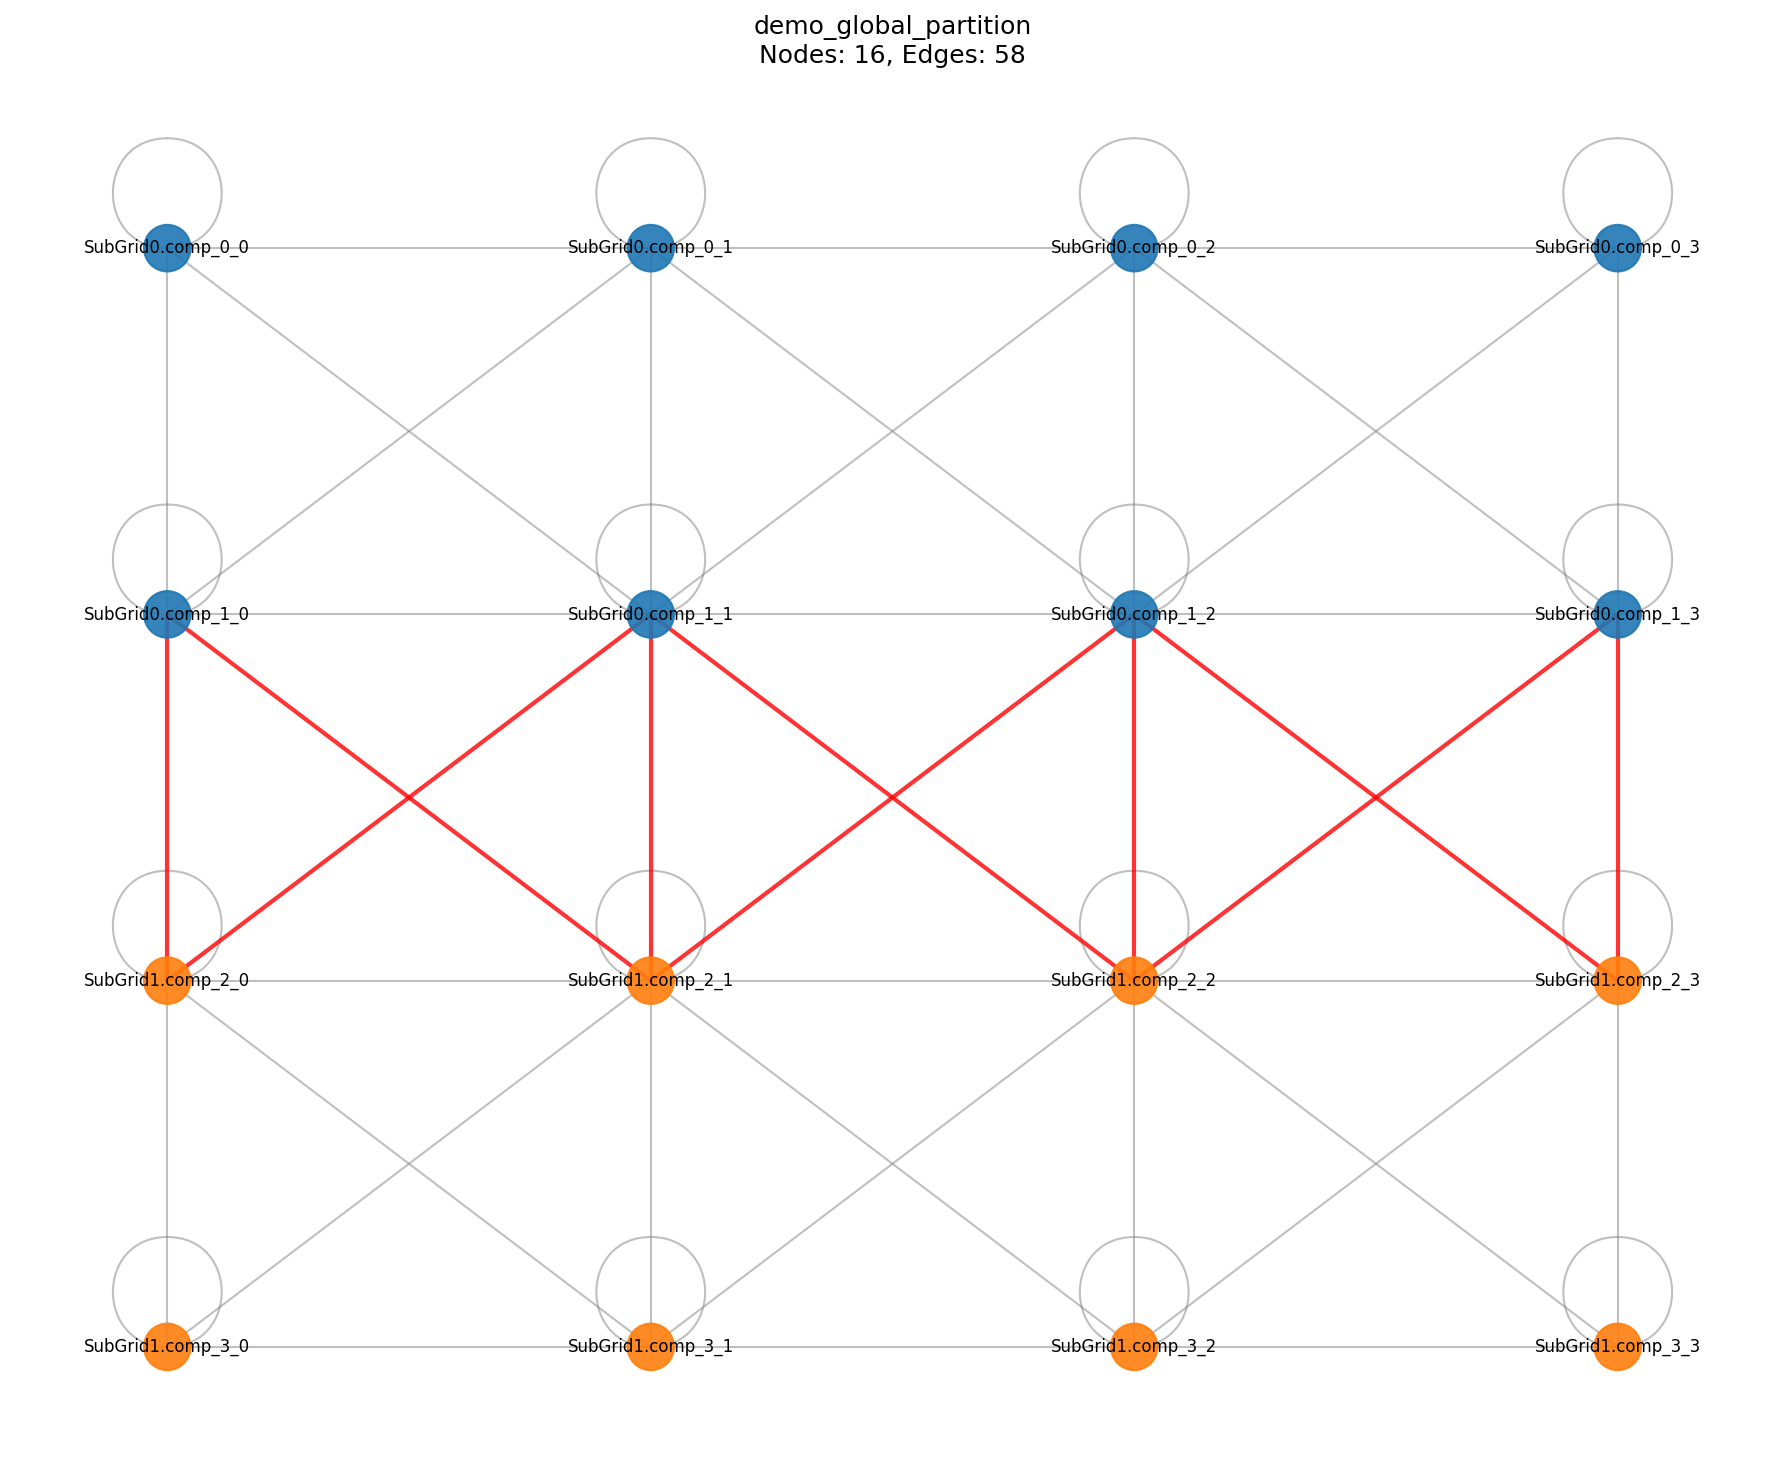

In [7]:
args.no_self_links = False
graph = make_graph()
print(f'{len(graph.devices)} devices, {len(graph.links)} links')

graph.write_networkx(
    'demo_global_partition',
    output=OUTPUT_DIR,
    hierarchy=False,
    color_by_partition=True,
    highlight_inter_rank=True,
    self_links=True,
    full_labels=True,
    layout=grid_layout,
)
show_image(f'{OUTPUT_DIR}/demo_global_partition.png')


## Demo 2 — Per-rank views

Instead of the whole topology, render one image per rank. Each image shows the
devices that rank owns plus the boundary neighbors it links to. Inter-rank
links are still highlighted in red so you can see where each rank connects to
its neighbors.

rank 0: 12 devices, 34 links


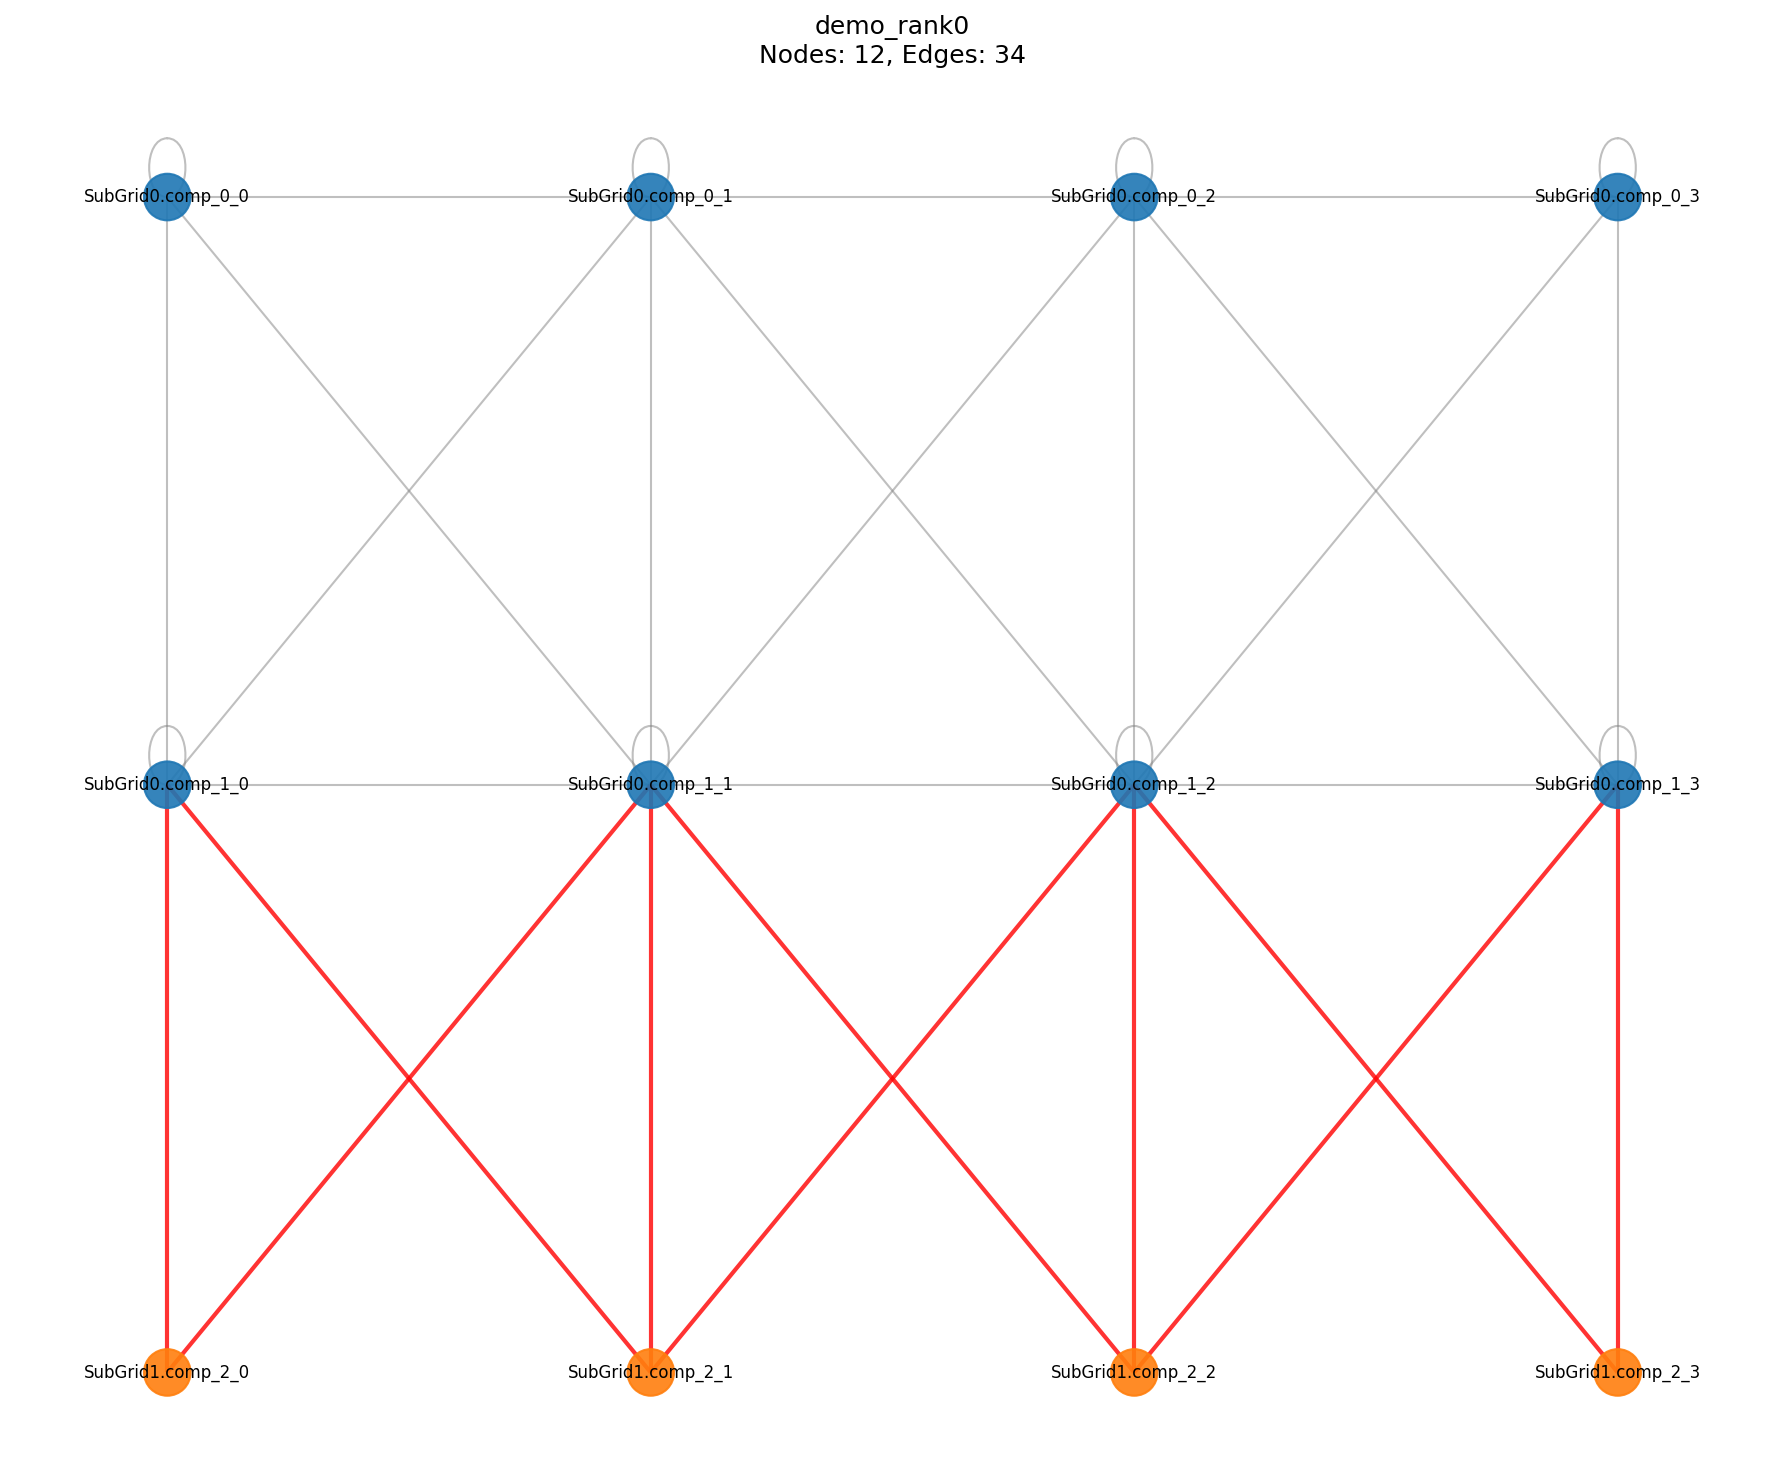

rank 1: 12 devices, 34 links


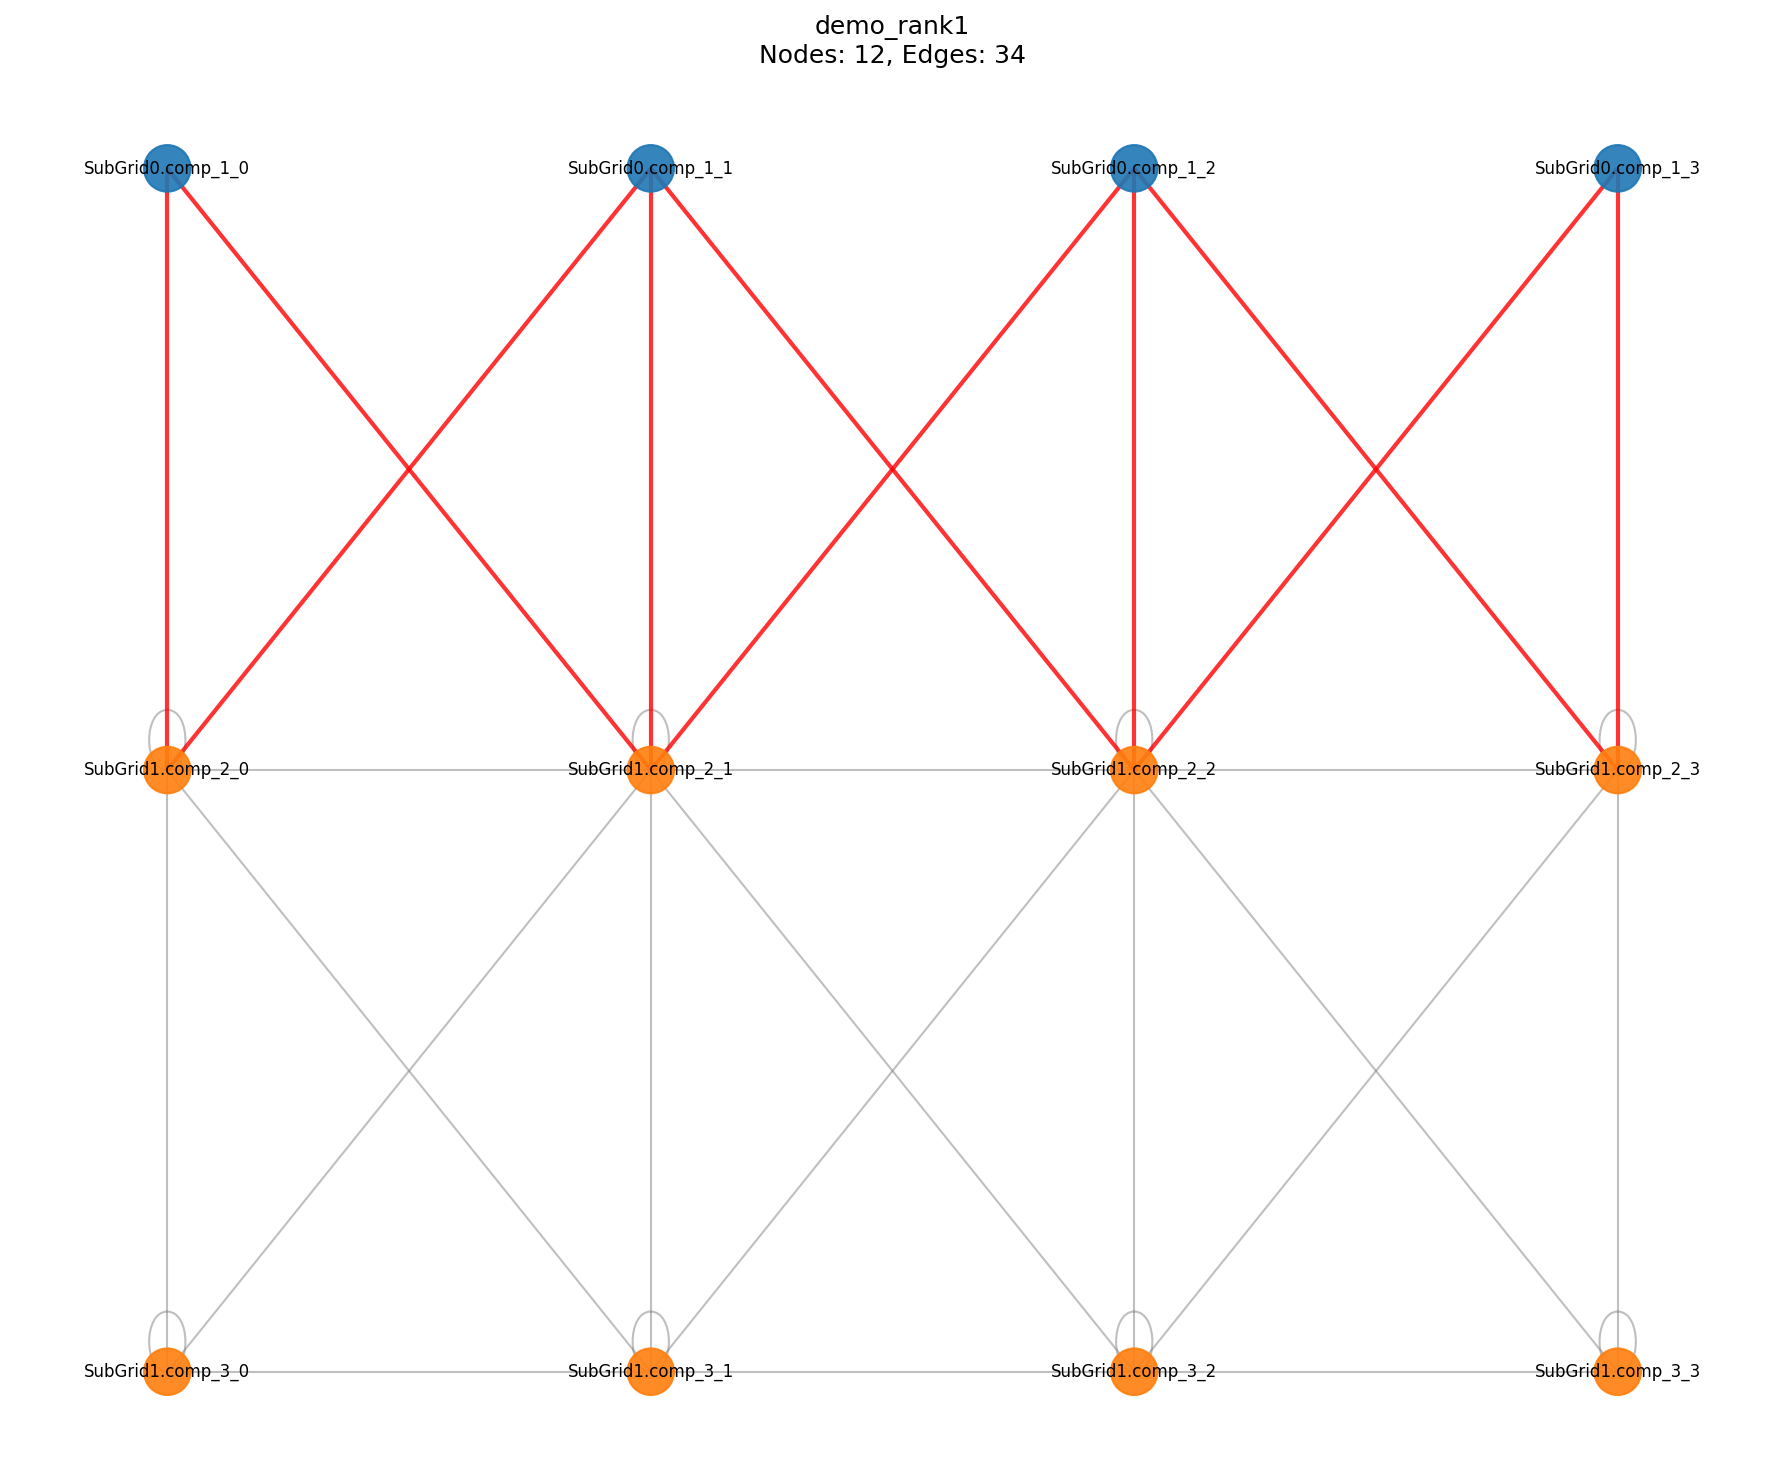

In [8]:
for r in range(args.num_ranks):
    g = make_rank_graph(r)
    name = f'demo_rank{r}'
    print(f'rank {r}: {len(g.devices)} devices, {len(g.links)} links')
    g.write_networkx(
        name,
        output=OUTPUT_DIR,
        hierarchy=False,
        color_by_partition=True,
        highlight_inter_rank=True,
        self_links=True,
        full_labels=True,
        layout=grid_layout,
    )
    show_image(f'{OUTPUT_DIR}/{name}.png')


## Demo 3 — Toggle off: no coloring, no inter-rank highlight

For comparison, render with partition coloring and inter-rank highlighting
disabled.

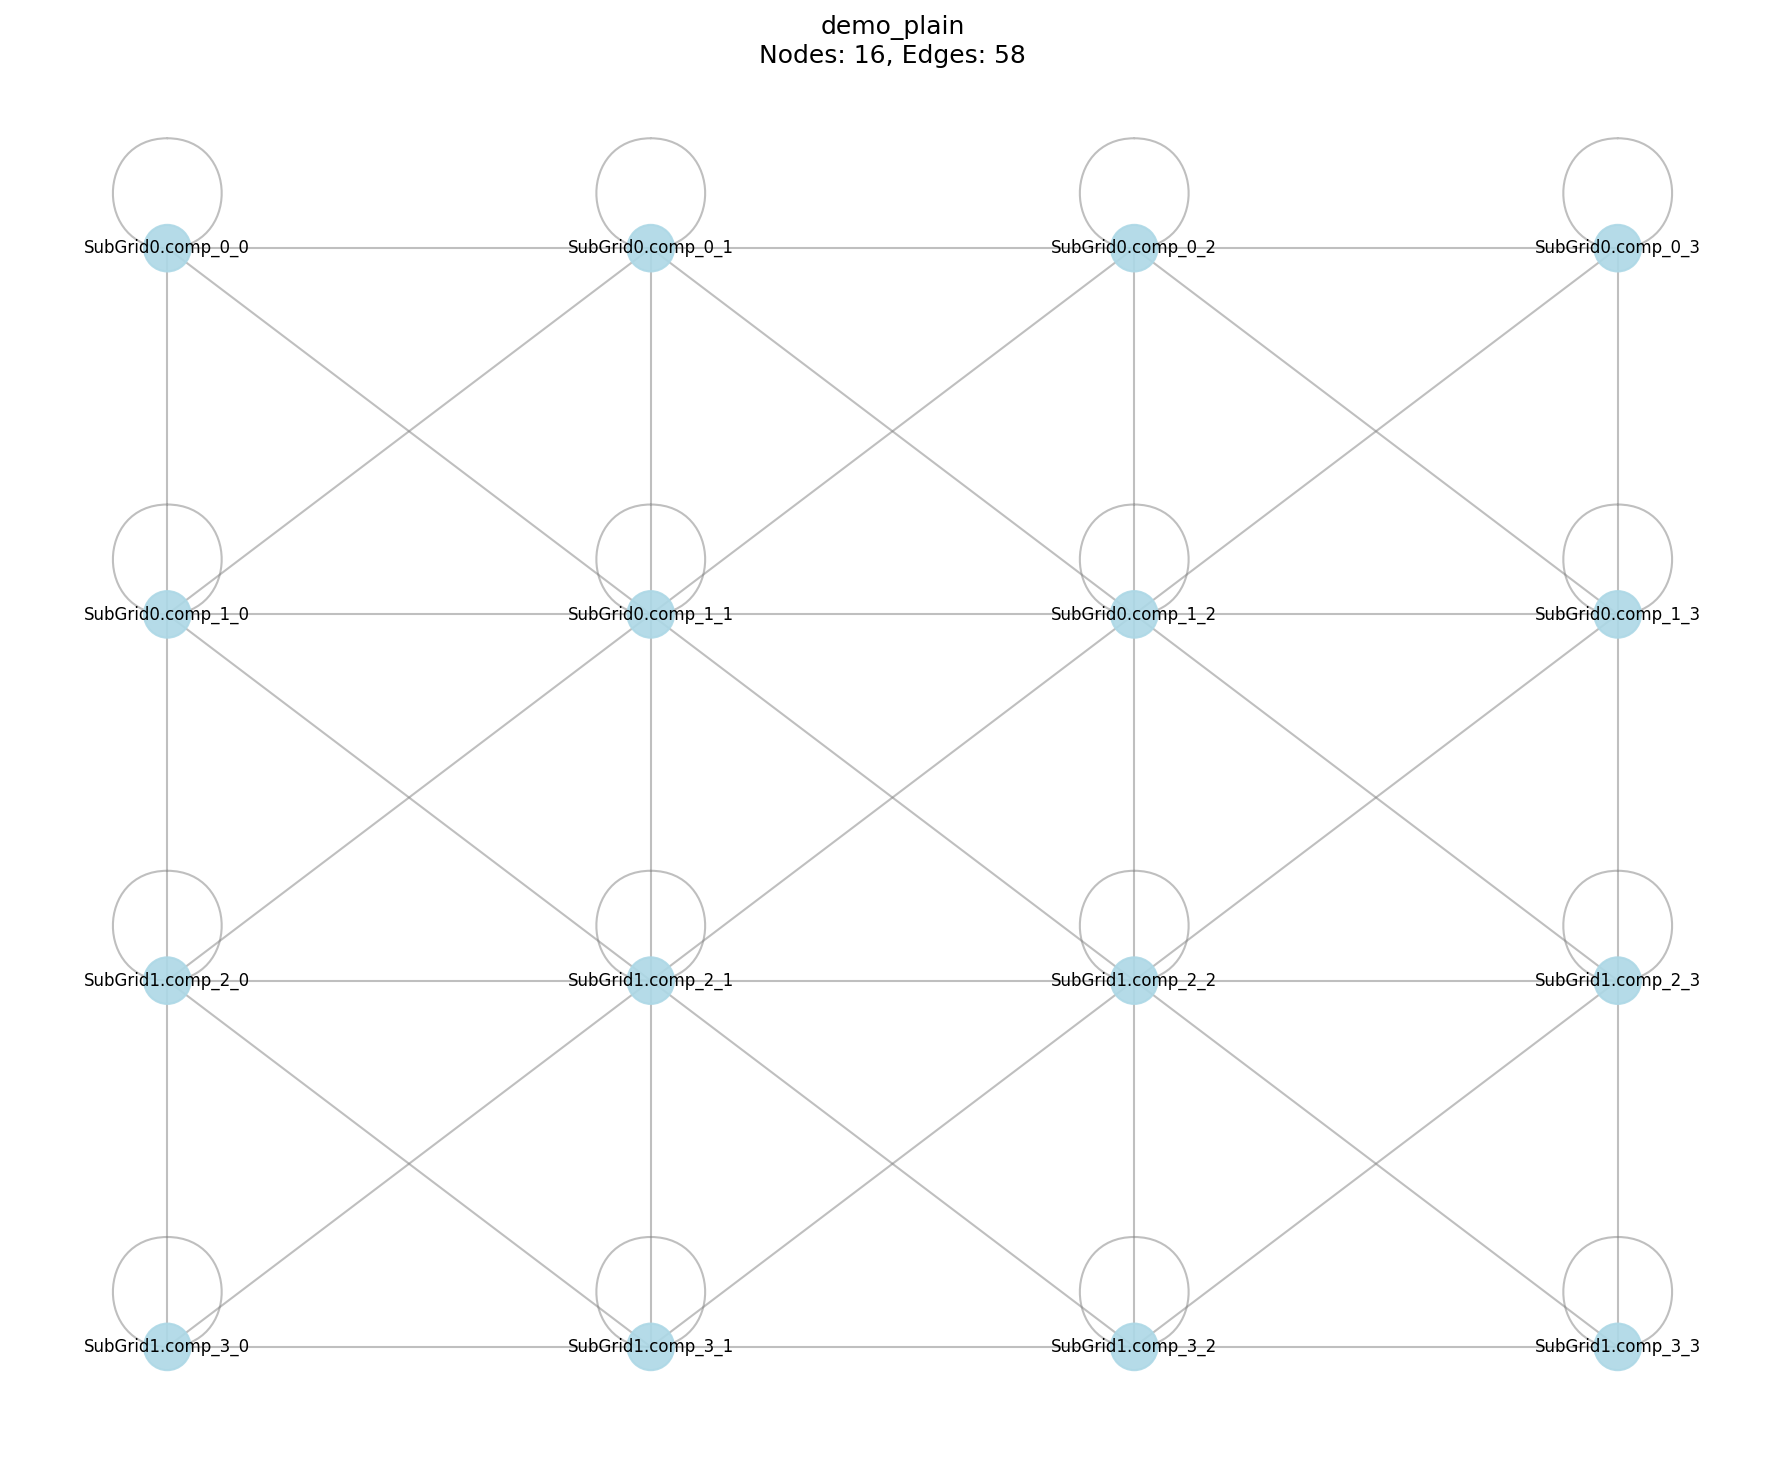

In [9]:
graph = make_graph()
graph.write_networkx(
    'demo_plain',
    output=OUTPUT_DIR,
    hierarchy=False,
    color_by_partition=False,
    highlight_inter_rank=False,
    self_links=True,
    full_labels=True,
    layout=grid_layout,
)
show_image(f'{OUTPUT_DIR}/demo_plain.png')


## Demo 4 — Save the NetworkX graph as a pickle

In addition to rendering the image, save the underlying NetworkX graph to a
Python pickle via `save_graph`. The format is chosen from the extension
(`.pickle` / `.pkl` / `.gpickle`). A bare filename is written into the output
folder.

In [10]:
graph = make_graph()
graph.write_networkx(
    'demo_saved_pickle',
    output=OUTPUT_DIR,
    hierarchy=False,
    color_by_partition=True,
    highlight_inter_rank=True,
    full_labels=True,
    layout=grid_layout,
    save_graph='phold_grid.pickle',
)
print('Saved', f'{OUTPUT_DIR}/phold_grid.pickle')


Saved output/phold_grid.pickle


## Demo 5 — Save the NetworkX graph as GraphML

Save the same graph as GraphML via `save_graph='...graphml'`. GraphML only
supports scalar attributes, so any complex values are stringified on a copy
before writing.

In [11]:
graph = make_graph()
graph.write_networkx(
    'demo_saved_graphml',
    output=OUTPUT_DIR,
    hierarchy=False,
    color_by_partition=True,
    highlight_inter_rank=True,
    full_labels=True,
    layout=grid_layout,
    save_graph='phold_grid.graphml',
)
print('Saved', f'{OUTPUT_DIR}/phold_grid.graphml')


Saved output/phold_grid.graphml


## Demo 6 — Reload the saved graphs and render from them

Reload the pickle and the GraphML files, then generate an image directly from
each reloaded NetworkX graph using `DeviceGraph.render_networkx_graph`. This
confirms the saved graphs are self-contained and reproduce the same layout,
colors, and inter-rank highlighting.

pickle : Graph 16 nodes, 58 edges


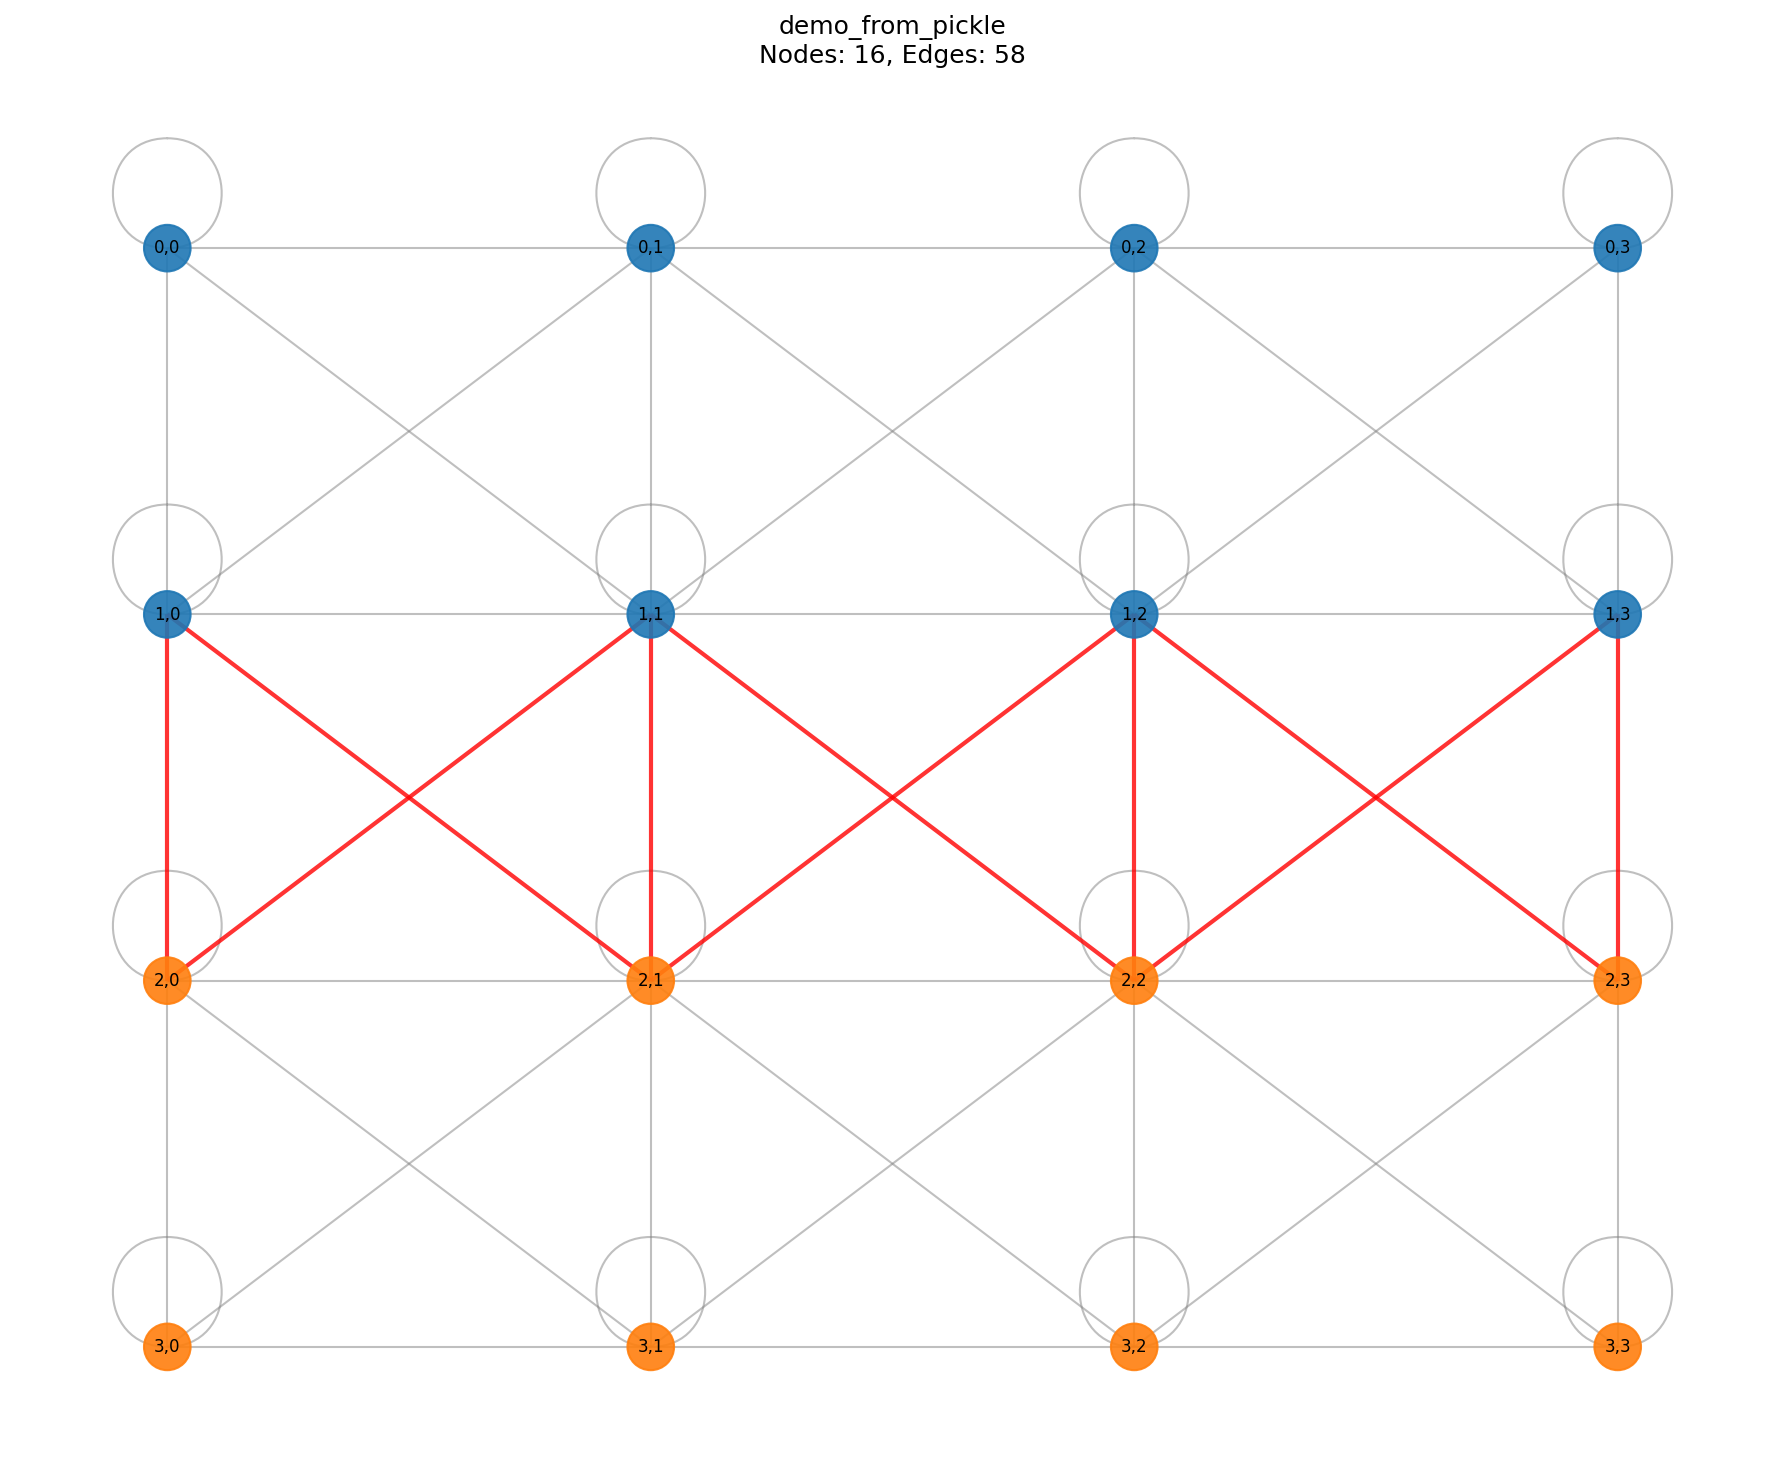

graphml: Graph 16 nodes, 58 edges


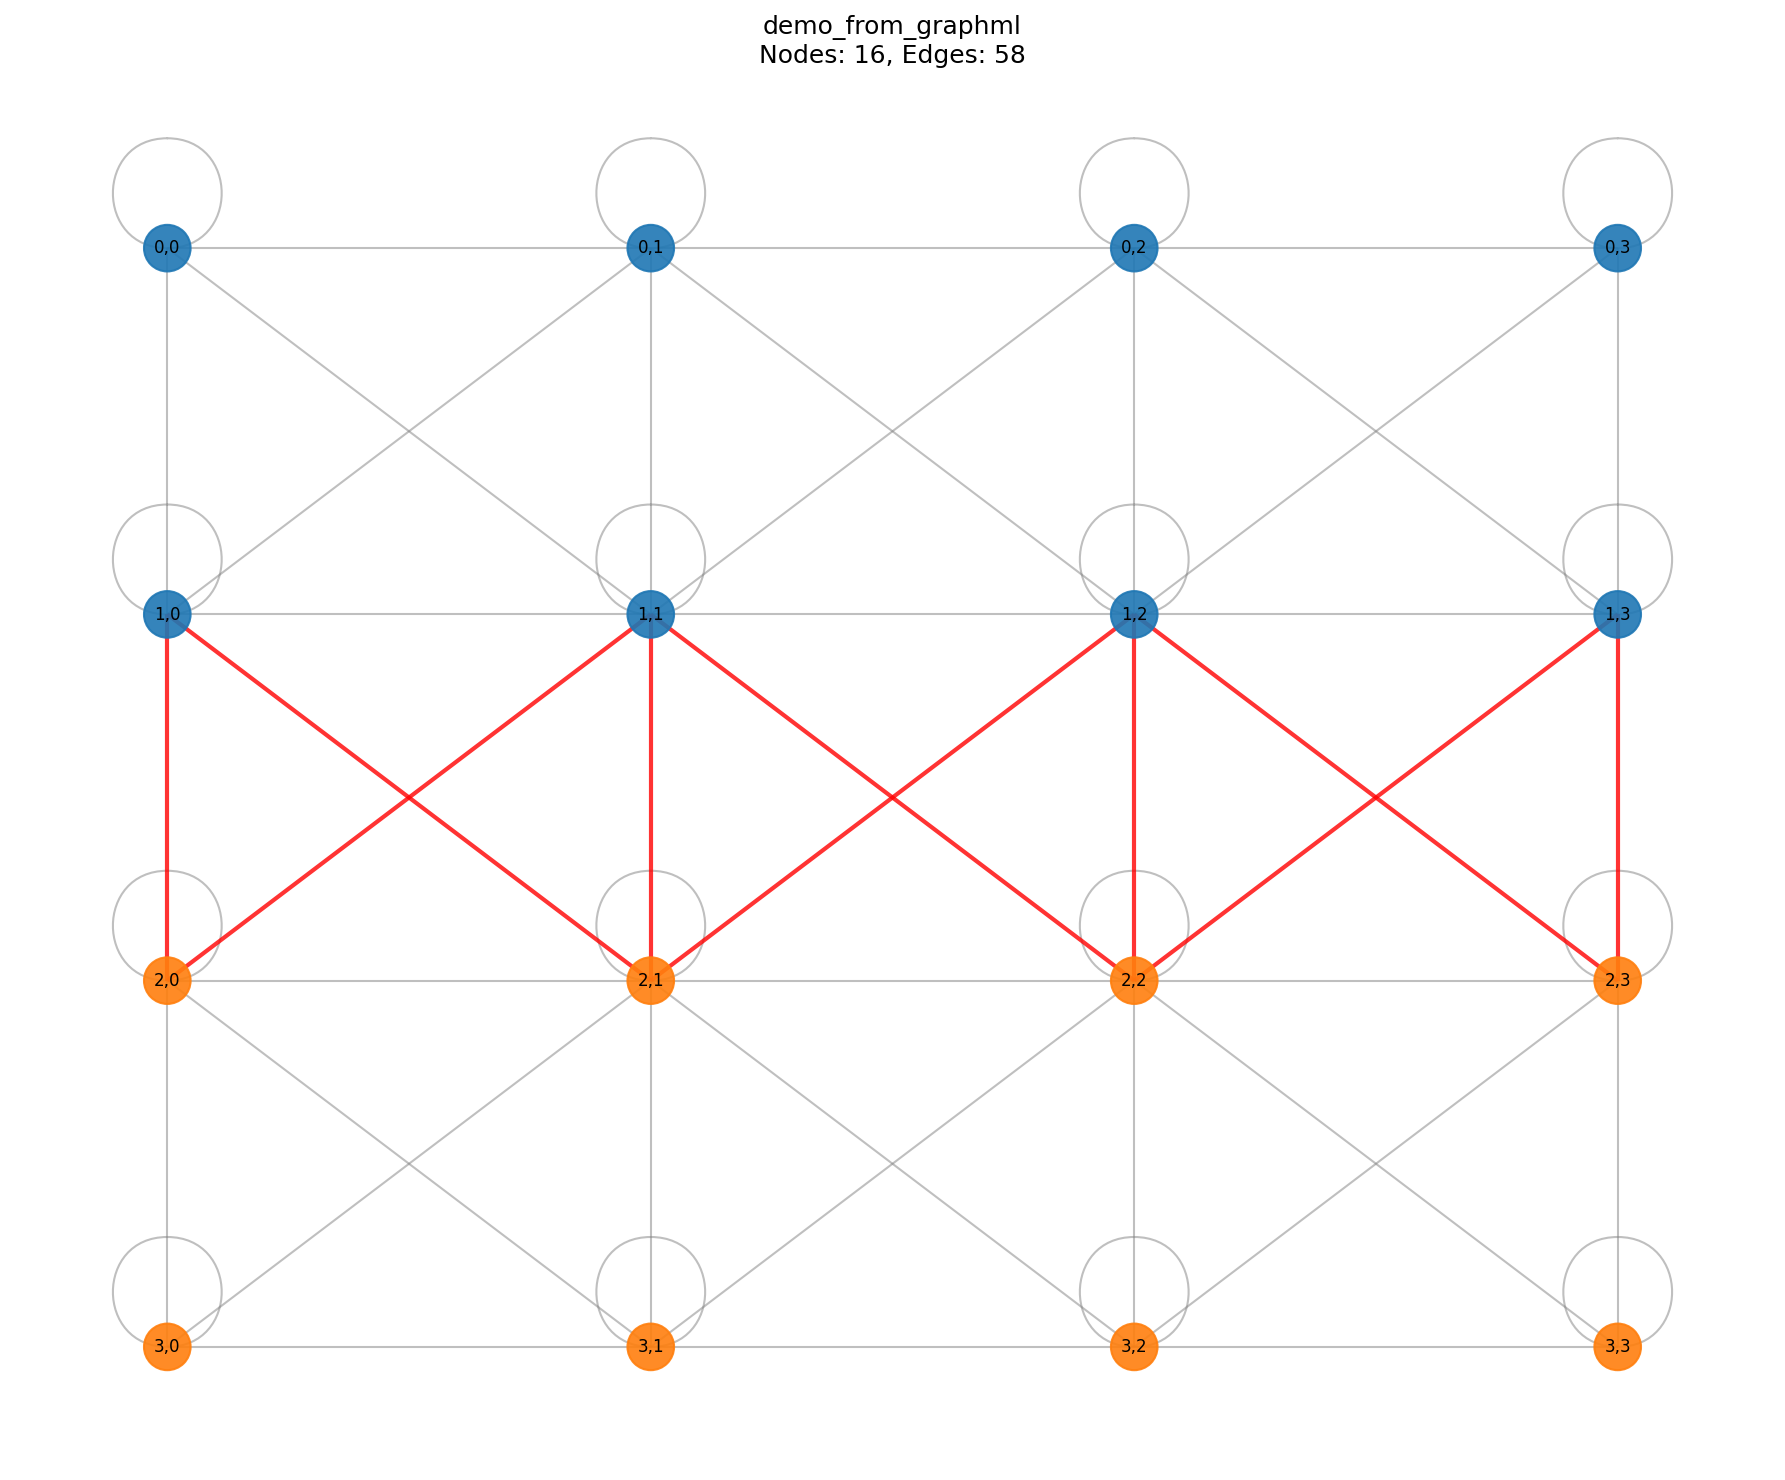

In [12]:
import pickle
import networkx as nx

# Reload the pickle and render an image directly from the reloaded graph.
with open(f'{OUTPUT_DIR}/phold_grid.pickle', 'rb') as f:
    G_pickle = pickle.load(f)
print('pickle :', type(G_pickle).__name__,
      G_pickle.number_of_nodes(), 'nodes,',
      G_pickle.number_of_edges(), 'edges')
DeviceGraph.render_networkx_graph(G_pickle, 'demo_from_pickle',
                                  output=OUTPUT_DIR,
                                  layout=grid_layout, node_label=grid_label)
show_image(f'{OUTPUT_DIR}/demo_from_pickle.png')

# Reload the GraphML and render an image directly from the reloaded graph.
G_graphml = nx.read_graphml(f'{OUTPUT_DIR}/phold_grid.graphml')
print('graphml:', type(G_graphml).__name__,
      G_graphml.number_of_nodes(), 'nodes,',
      G_graphml.number_of_edges(), 'edges')
DeviceGraph.render_networkx_graph(G_graphml, 'demo_from_graphml',
                                  output=OUTPUT_DIR,
                                  layout=grid_layout, node_label=grid_label)
show_image(f'{OUTPUT_DIR}/demo_from_graphml.png')


## Demo 7 — Render with the DOT (graphviz) backend

`write_dot` produces graphviz `.dot` and `.svg` files. This requires
`pygraphviz` and the `dot` executable to be available. We write both a global
DOT/SVG and one DOT/SVG per rank; the per-rank `.dot` files feed the
DOT → NetworkX demos below.

Fontconfig warning: "/usr/share/fontconfig/conf.avail/05-reset-dirs-sample.conf", line 6: unknown element "reset-dirs"


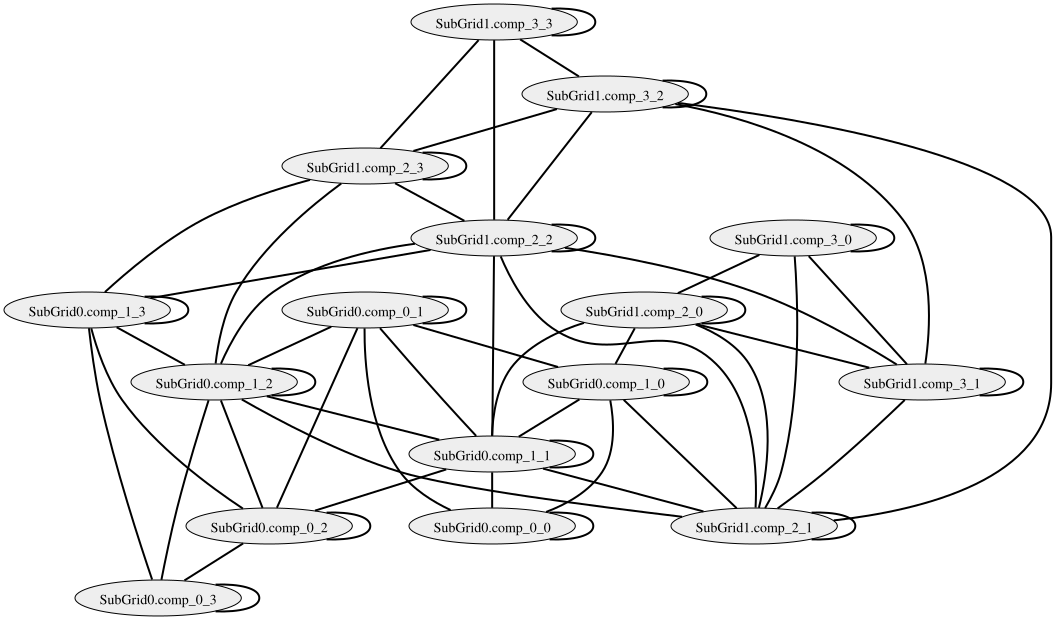

wrote output/demo_dot_rank0.dot
wrote output/demo_dot_rank1.dot


In [13]:
# Global DOT/SVG for the whole topology.
graph = make_graph()
graph.write_dot('demo_dot', output=OUTPUT_DIR, draw=True, hierarchy=False)
show_image(f'{OUTPUT_DIR}/demo_dot.svg')

# One DOT/SVG per rank (used by the per-rank DOT -> NetworkX demo below).
for r in range(args.num_ranks):
    make_rank_graph(r).write_dot(f'demo_dot_rank{r}', output=OUTPUT_DIR,
                                 draw=True, hierarchy=False)
    print('wrote', f'{OUTPUT_DIR}/demo_dot_rank{r}.dot')

## Demo 8 — DOT files to NetworkX (combined)

`DeviceGraph.dot_to_networkx` reads existing `.dot` files (such as those
written in Demo 7) and renders them as NetworkX images. With `combine=True`
all DOT files in the directory are merged into a single image.

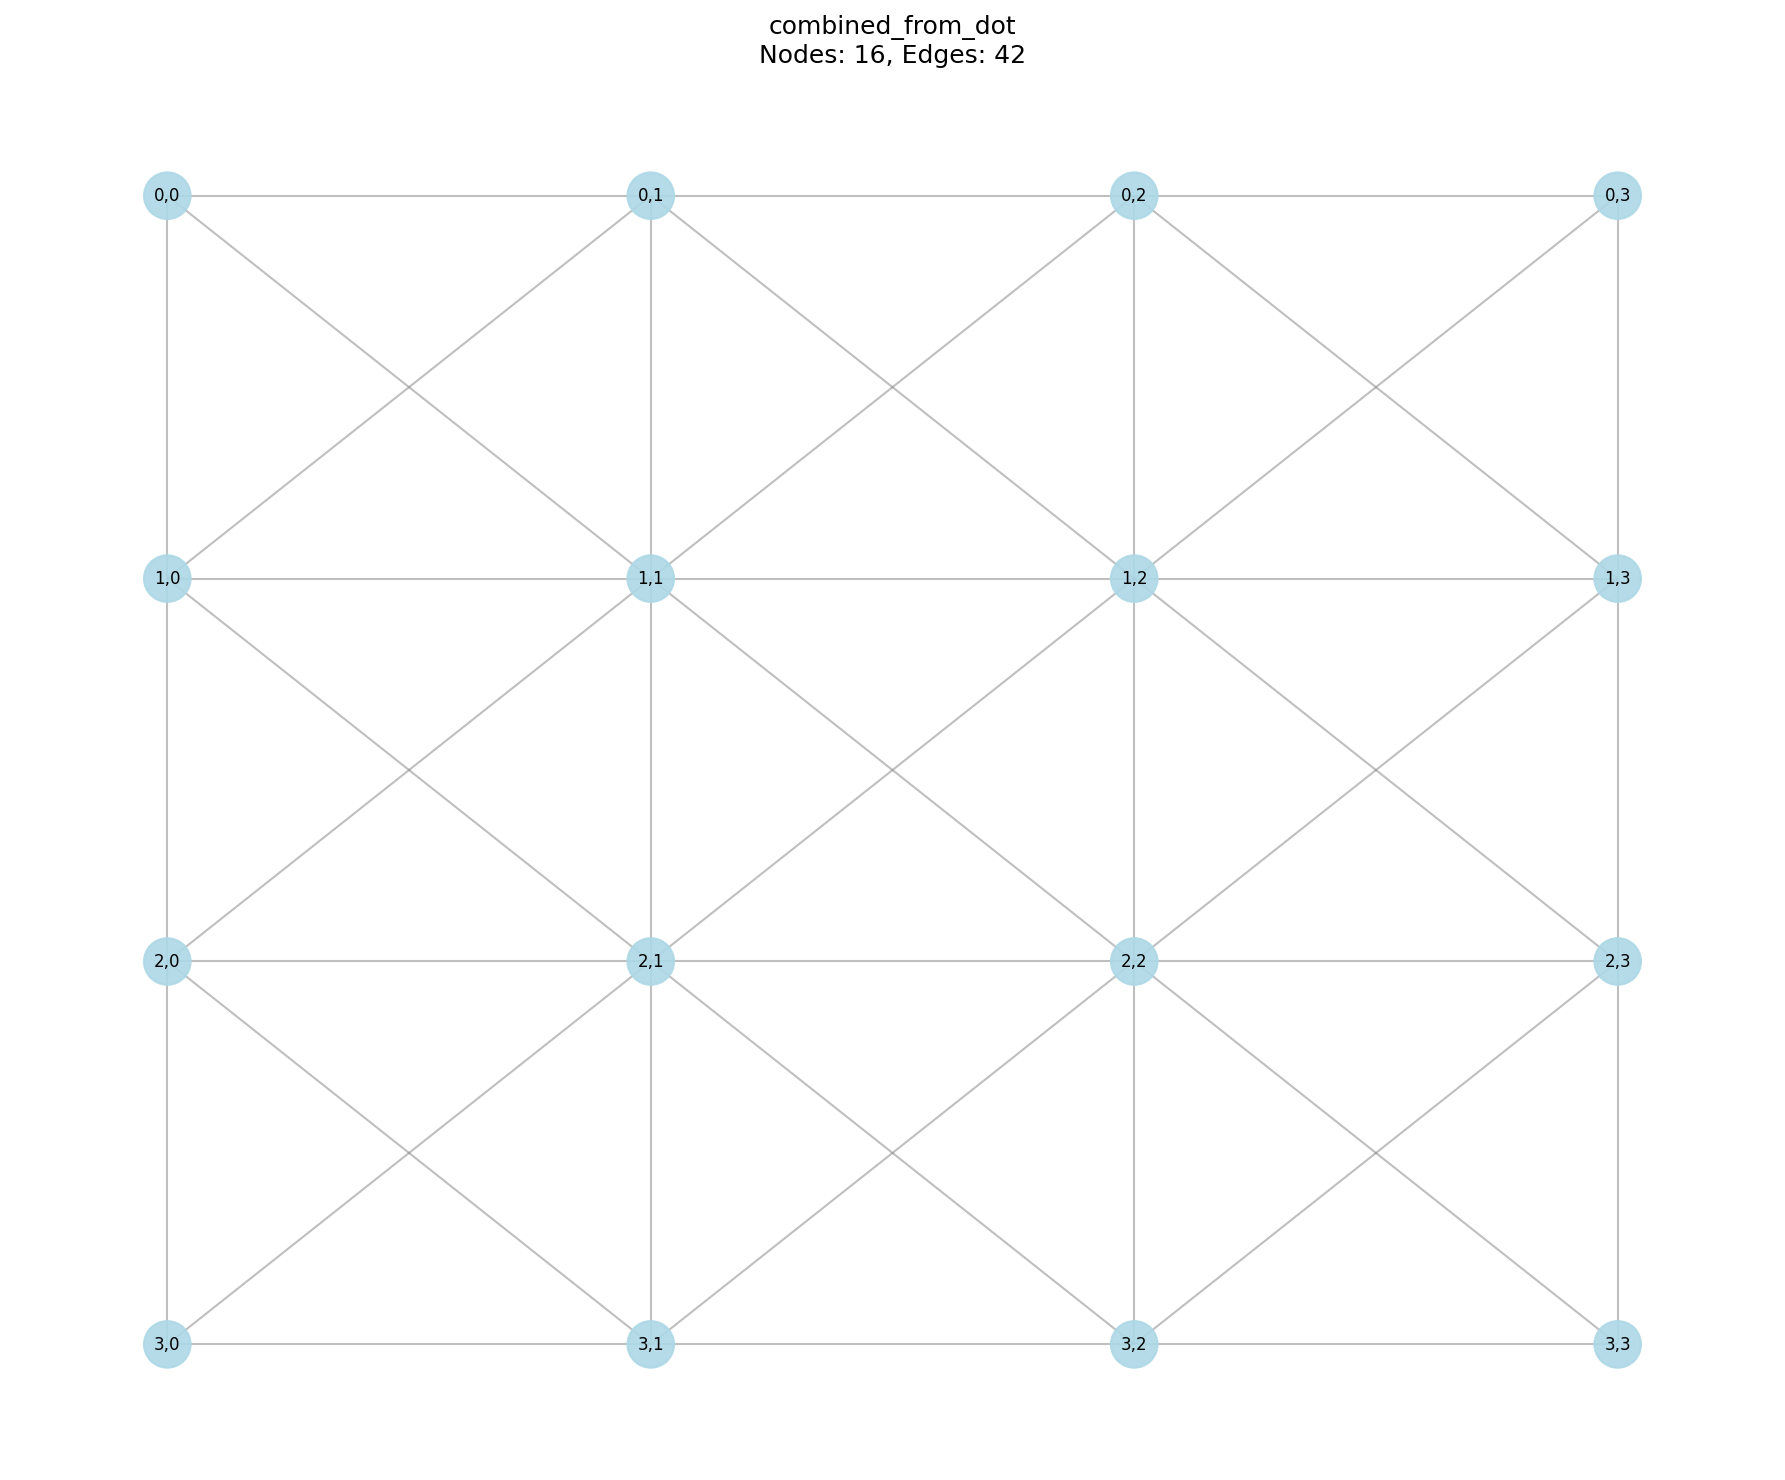

In [14]:
DeviceGraph.dot_to_networkx(OUTPUT_DIR, output=OUTPUT_DIR, combine=True,
                            layout=grid_layout, node_label=grid_label)
show_image(f'{OUTPUT_DIR}/combined_from_dot.png')


## Demo 9 — DOT files to NetworkX (per-rank, left separate)

The same reader with `combine=False` renders each `.dot` file to its own
image instead of merging them. Here we display the per-rank images produced
from the per-rank DOT files written in Demo 7.

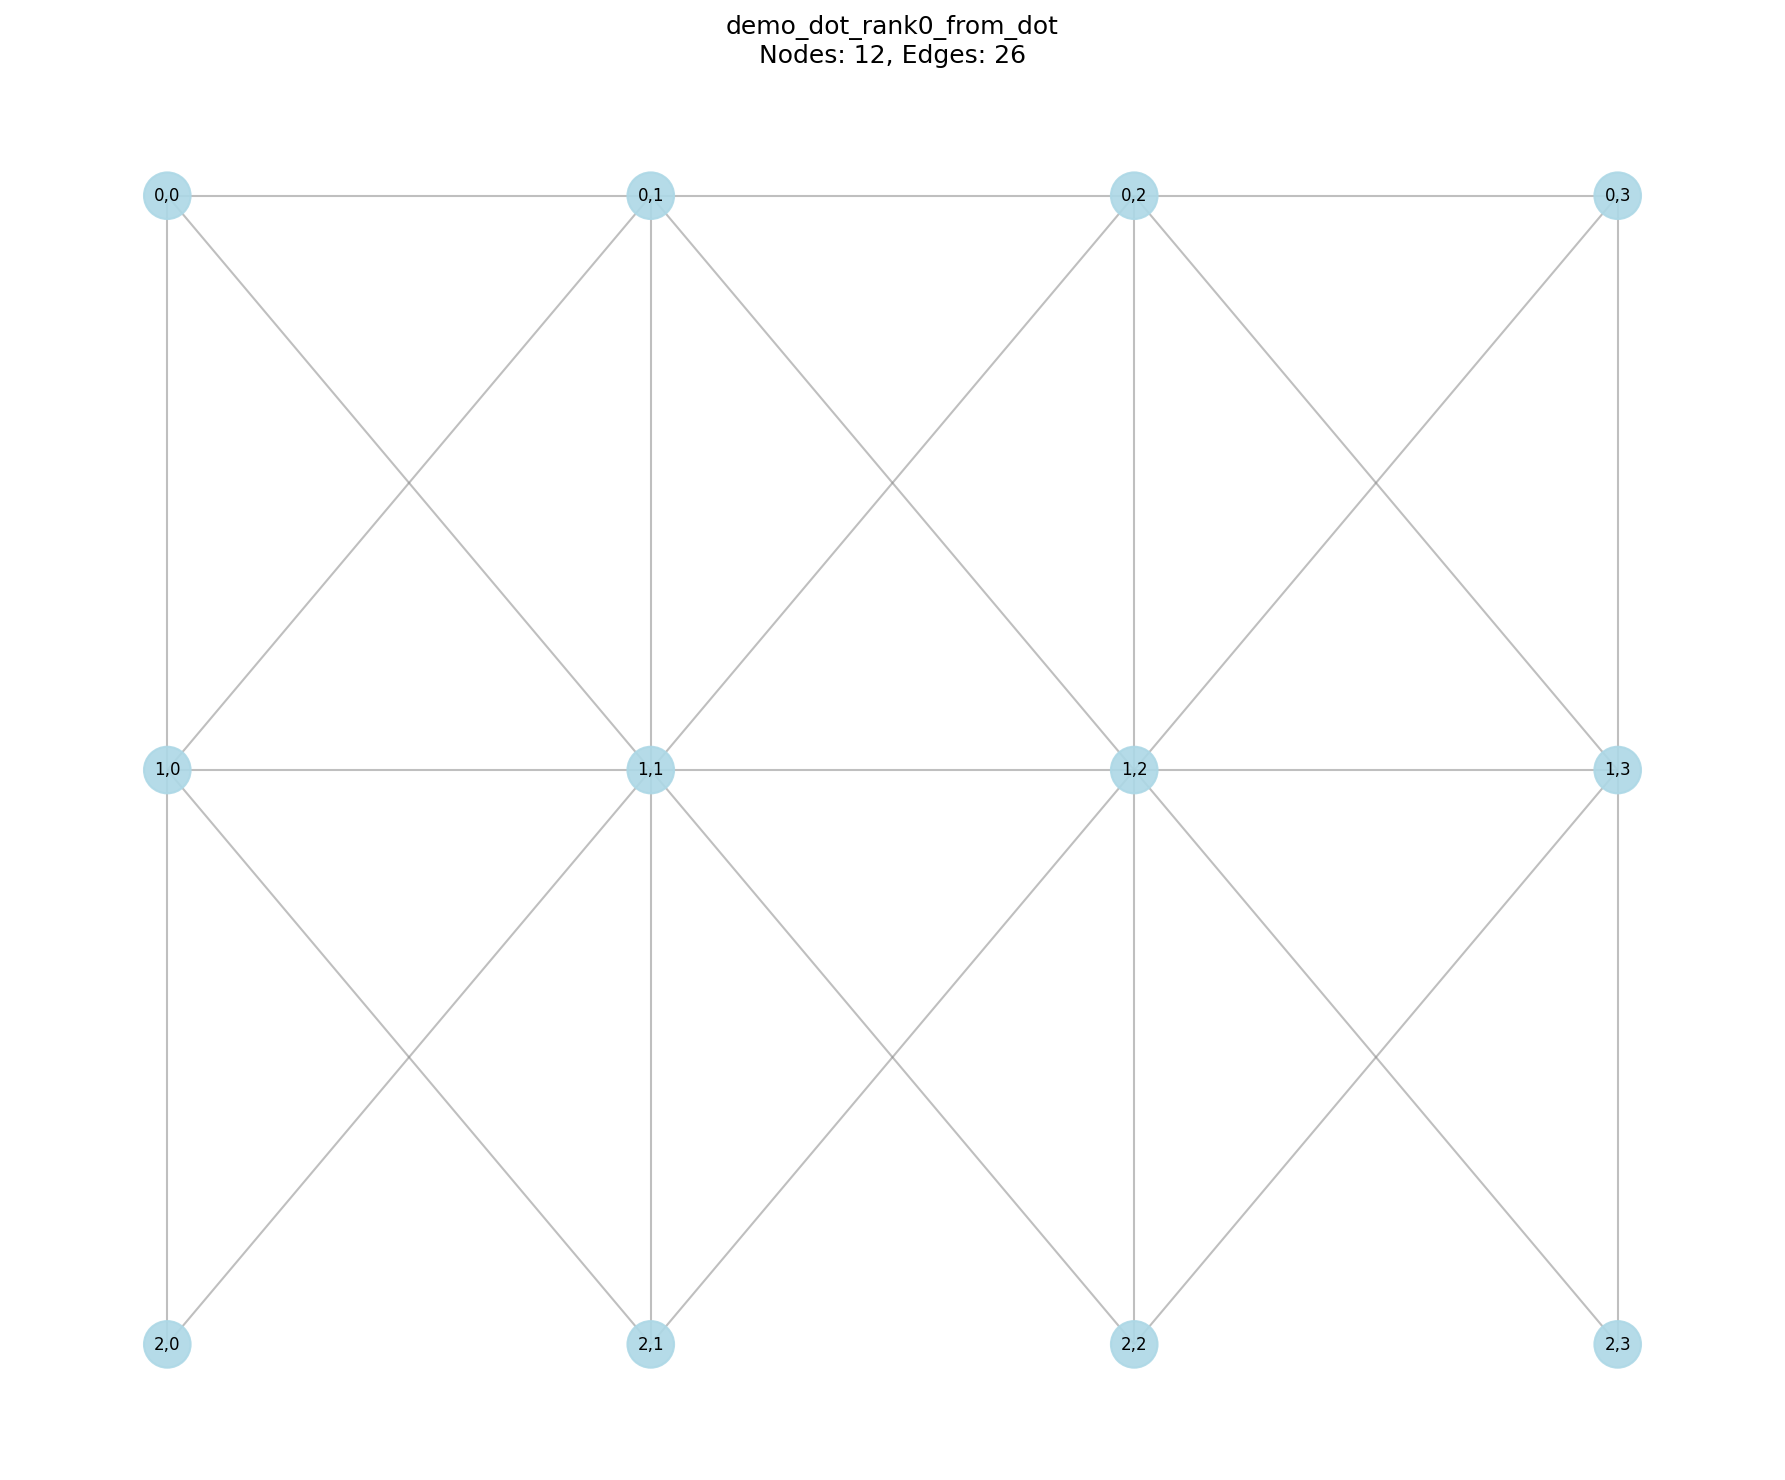

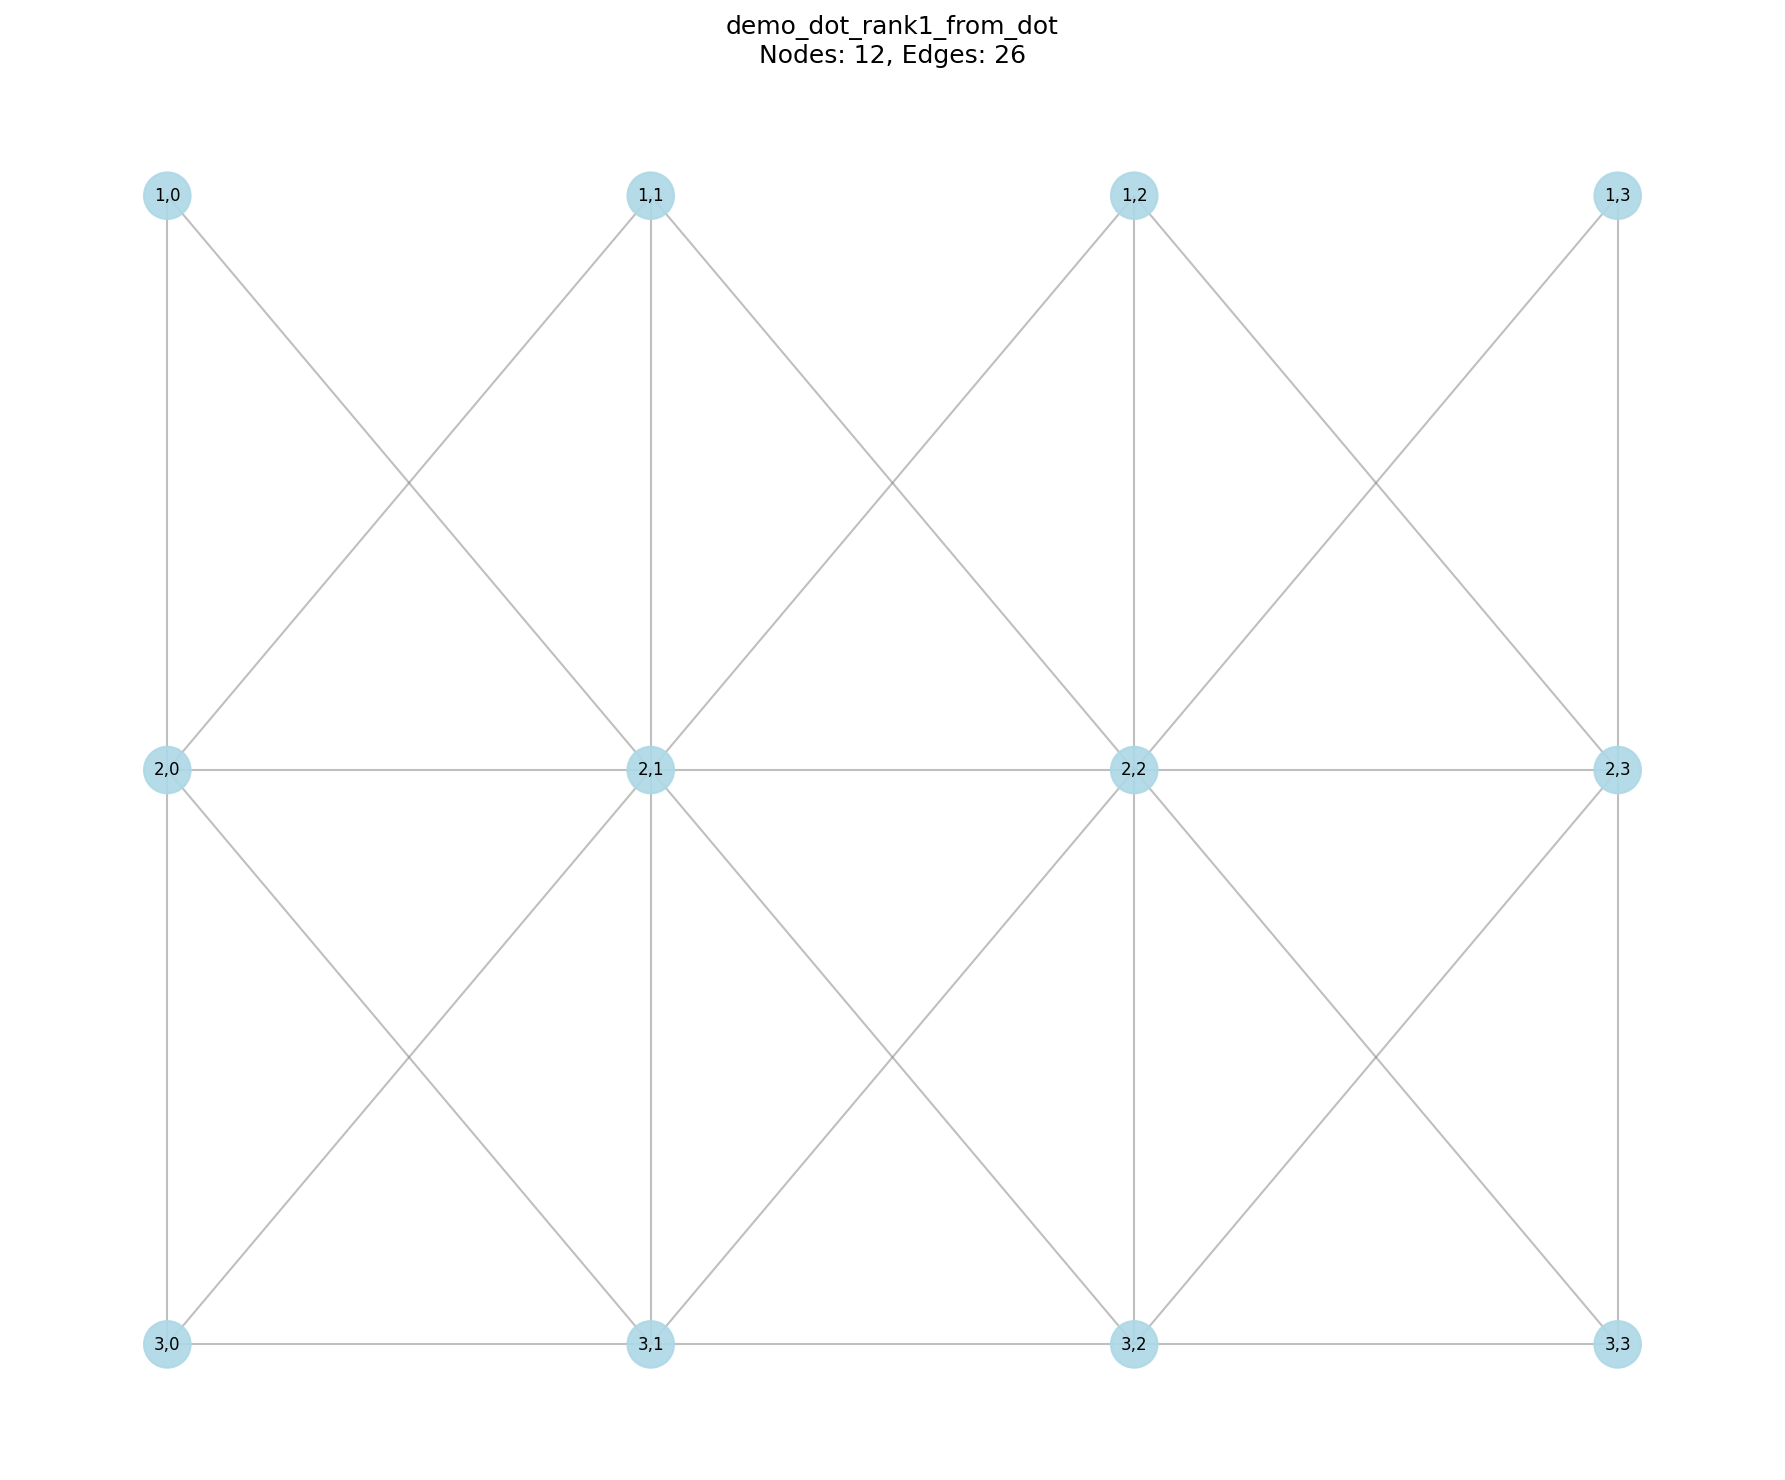

In [15]:
# With combine=False, each .dot file is rendered to its own image, leaving the
# per-rank views separate. Files are named <stem>_from_dot.png.
DeviceGraph.dot_to_networkx(OUTPUT_DIR, output=OUTPUT_DIR, combine=False,
                            layout=grid_layout, node_label=grid_label)
for r in range(args.num_ranks):
    show_image(f'{OUTPUT_DIR}/demo_dot_rank{r}_from_dot.png')


## Demo 10 — Hierarchy view: links between SubGrids only

Using `hierarchy=True` on an **unflattened** graph renders the top level as
just the `SubGrid` assemblies and the links between them, instead of every
individual component. This gives a compact, high-level view of how the
partitions connect, with the many parallel border links collapsed into a
single labeled edge.

2 top-level devices, 10 top-level links


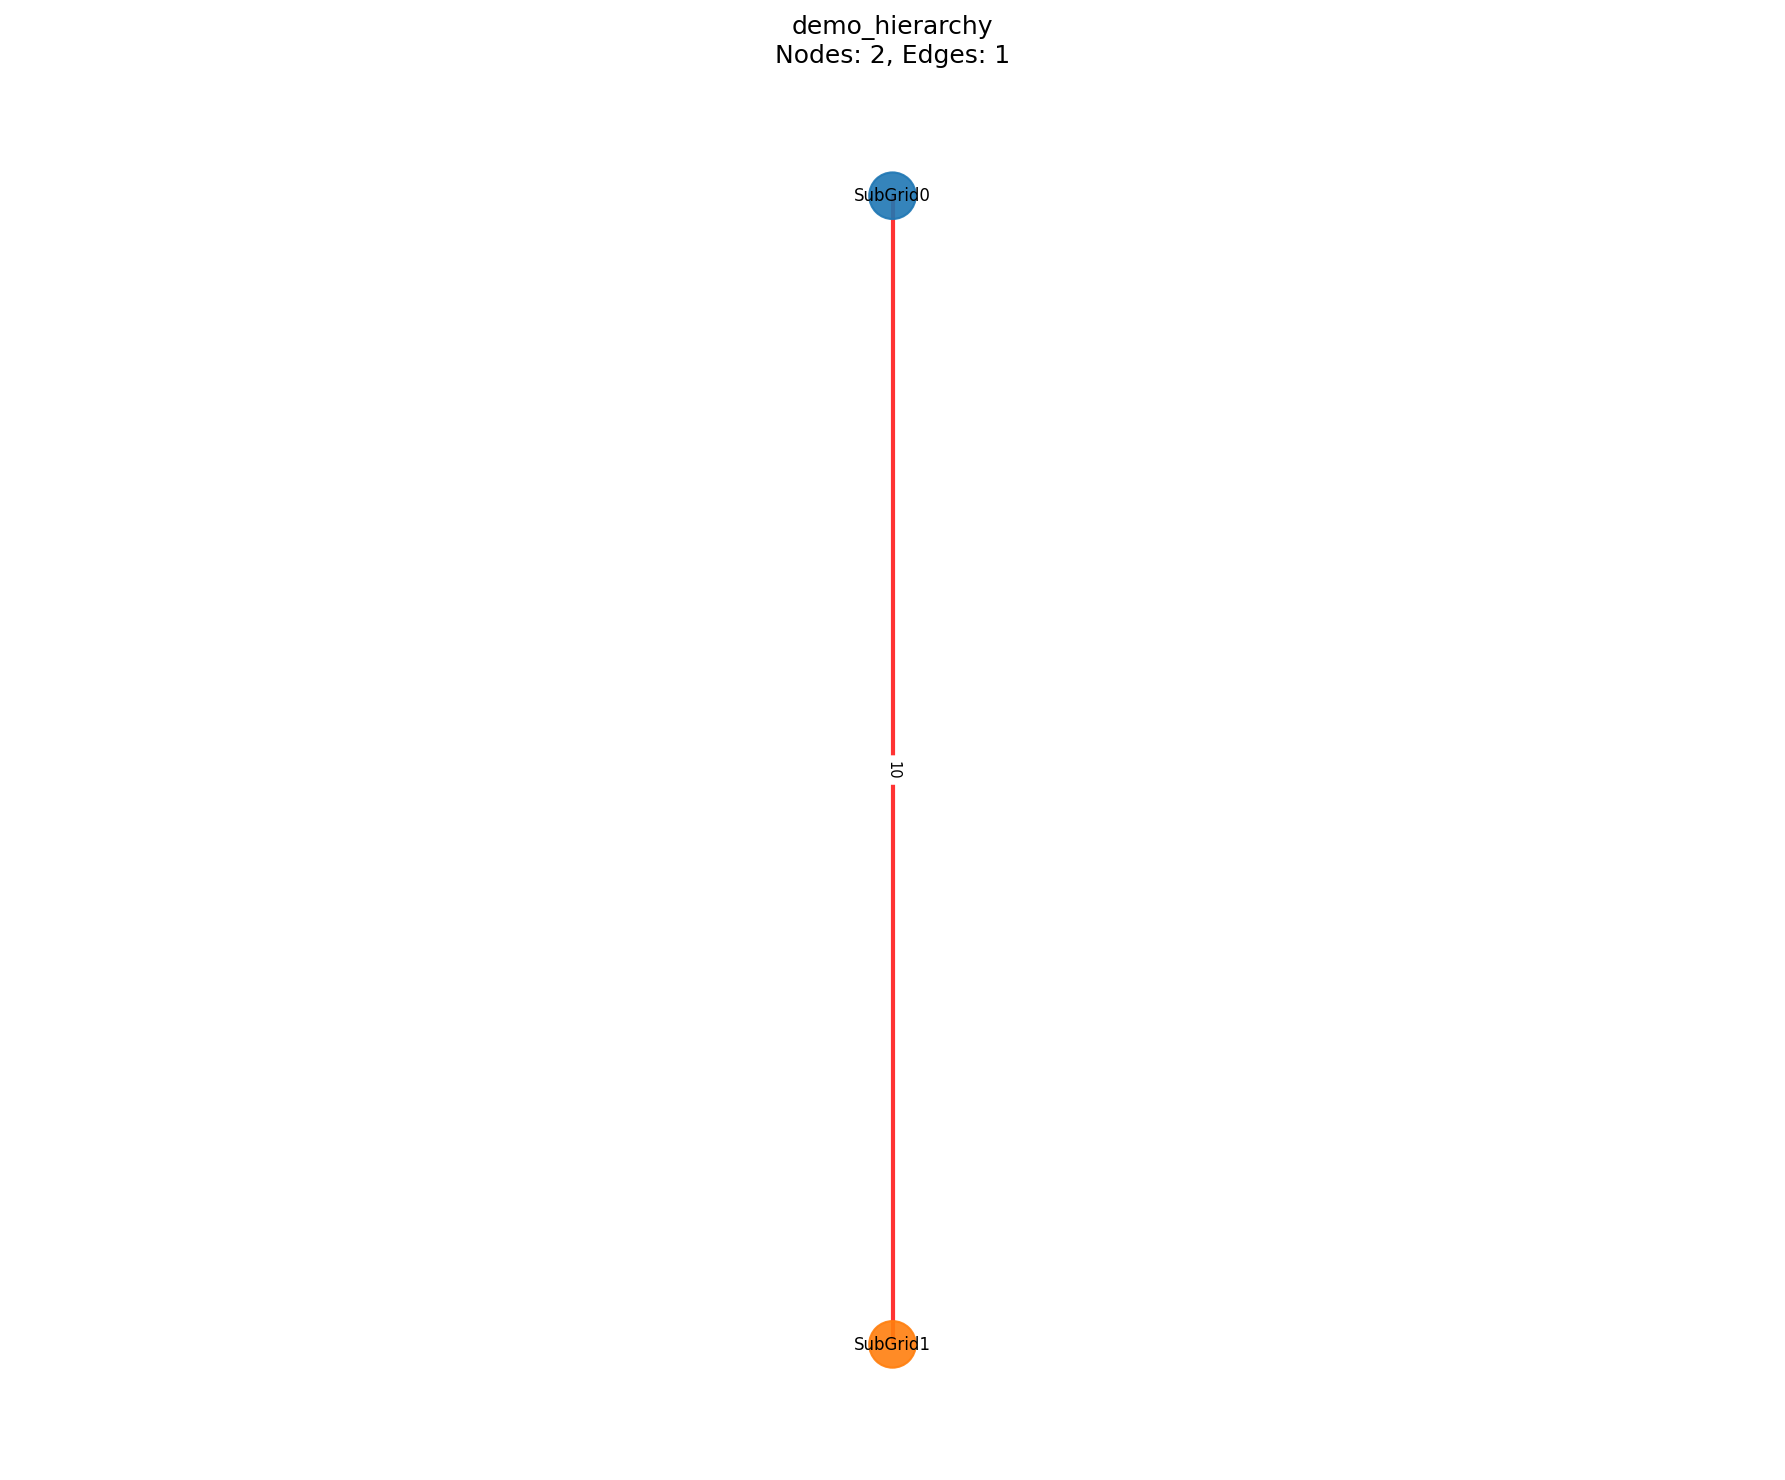

In [16]:
# Build the graph but do NOT flatten it, so the SubGrid assemblies stay
# intact. With hierarchy=True, the top-level image shows only the SubGrids and
# the links between them (the border links), not the individual components.
# Parallel border links are collapsed to a single edge labeled with their
# count. The recursion also writes a separate image per assembly type (e.g.
# SubGrid.png) showing each SubGrid's internals; grid_layout/grid_label keep
# those internal component images on a grid.
hier = architecture_global(args.num_ranks)
print(f'{len(hier.devices)} top-level devices, {len(hier.links)} top-level links')
hier.write_networkx(
    'demo_hierarchy',
    output=OUTPUT_DIR,
    hierarchy=True,
    color_by_partition=True,
    highlight_inter_rank=True,
    layout=grid_layout,
    node_label=grid_label,
)
show_image(f'{OUTPUT_DIR}/demo_hierarchy.png')


## Demo 11 — AHP's simple HPC example (a non-grid graph)

`ahp_graph` ships a small HPC cluster example under `examples/HPC`. It is built
from assemblies (`Rack`, `Server`) and SST-style submodules, wired together
with a 2D torus network. It is a good contrast to the PHOLD grid: its nodes are
**not** named `comp_row_col`, so we pass **no** `layout`/`node_label` callbacks
and let `ahp_graph` fall back to its automatic graphviz layout. This shows that
the generalized API renders arbitrary AHP graphs, not just grids.

We render two views, both with `hierarchy=False`:

- a **top-level** view of the un-flattened cluster — the four `Rack`
  assemblies and the 2D torus links between them, and
- a **one-level-expanded** view — each `Rack` expanded into its `Router`,
  `Server` assemblies, and torus-topology submodule.

We stop at one level of expansion rather than fully flattening: the HPC
`Server` assembly links directly to a submodule port (`CPU*_L1_to_L2`), which
the full-flatten path in this `ahp_graph` branch does not support. Expanding
only the racks avoids that path while still showing more of the hierarchy.

If `ahp_graph/examples/HPC` is not found next to this workspace, skip this demo.


HPC cluster (top level): 4 devices, 8 links


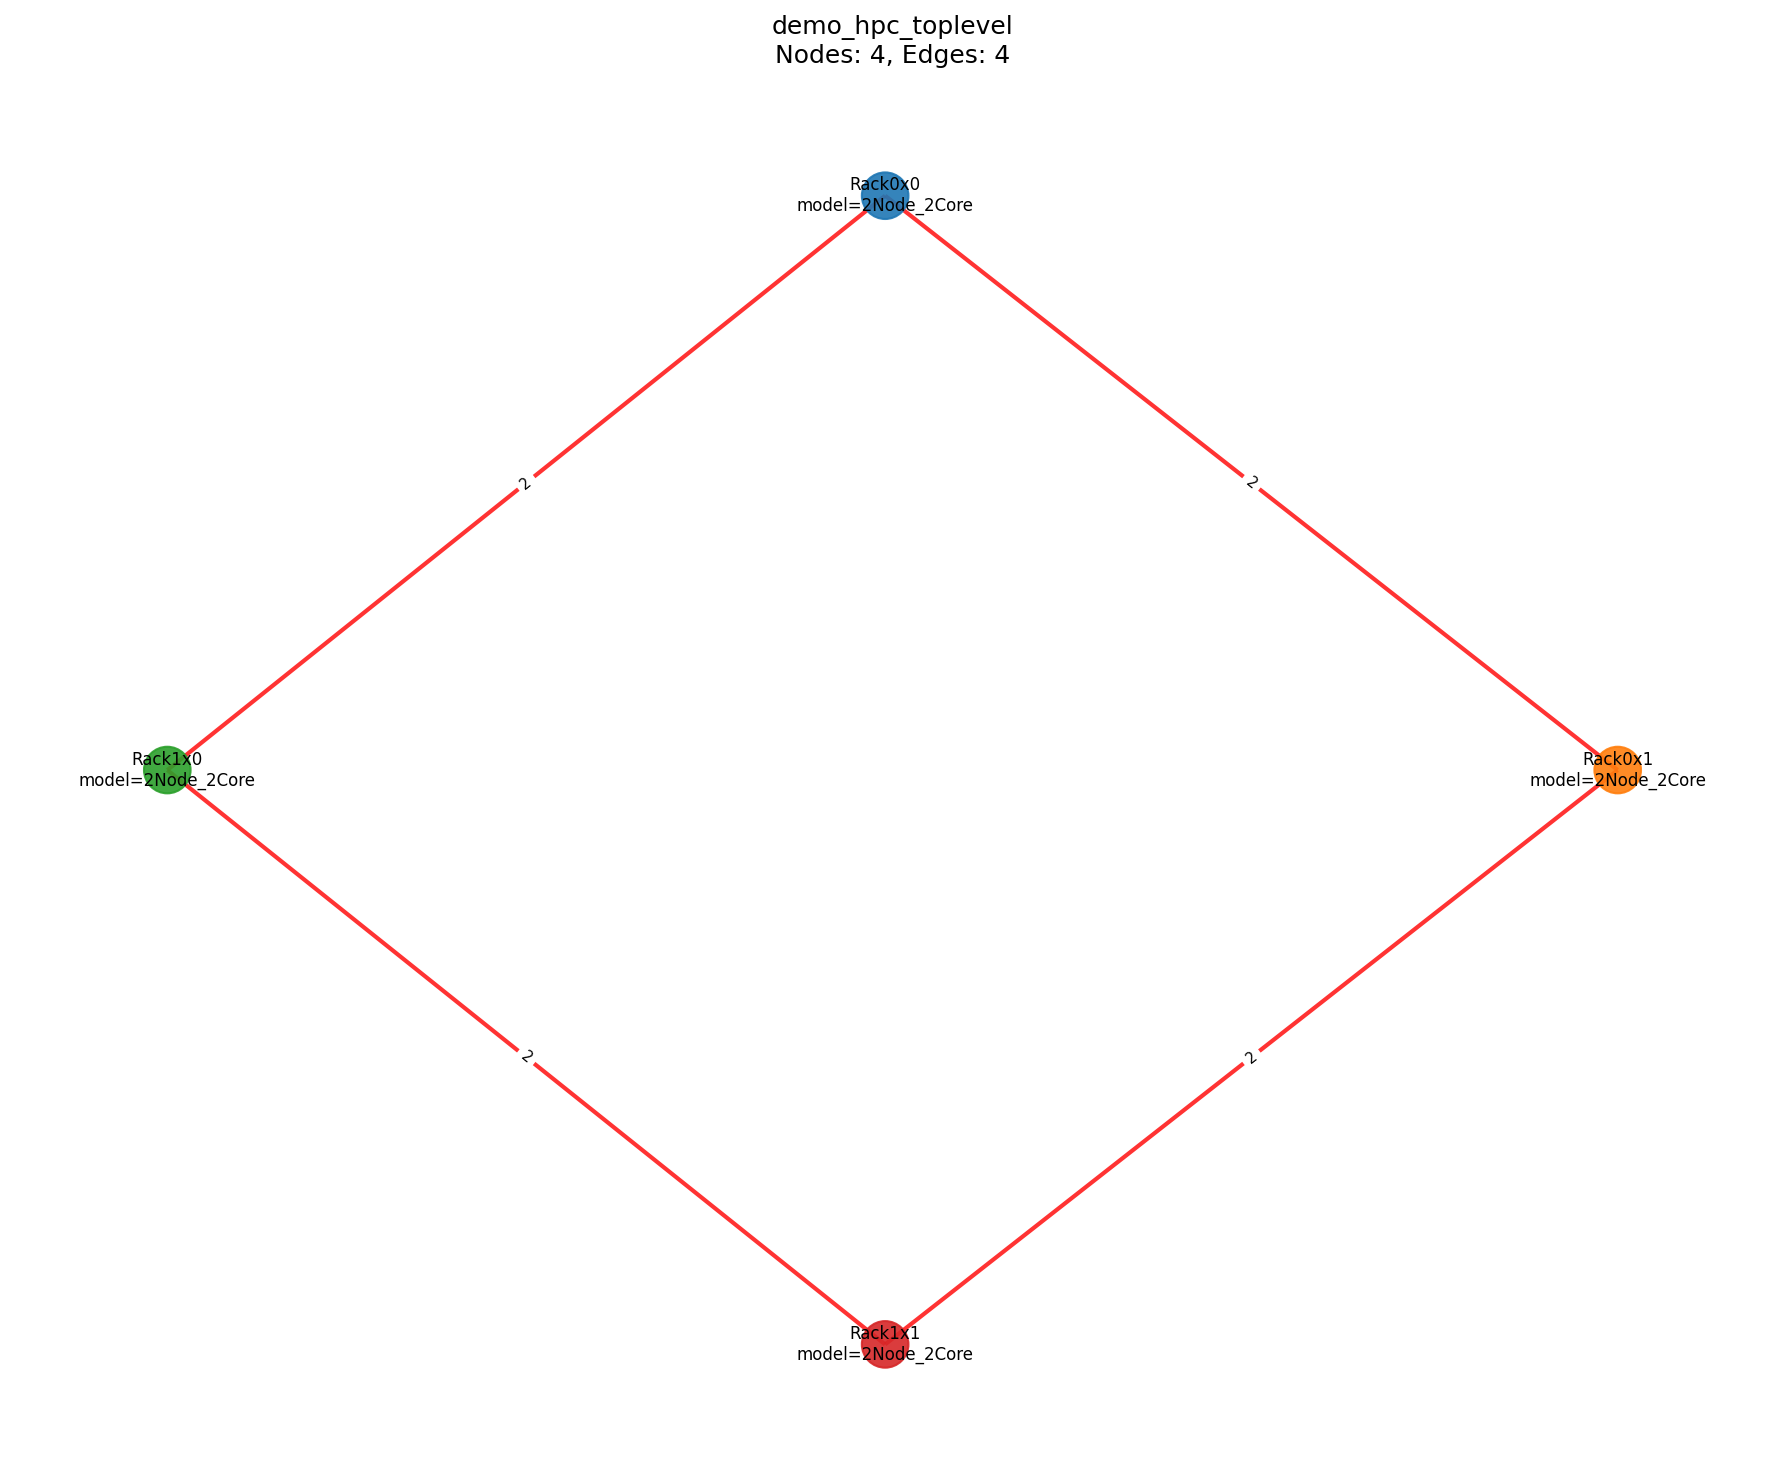

In [22]:
import importlib

# ahp_graph ships a small HPC cluster example. Add it to sys.path so its
# modules (which use bare 'from server import *' style imports) resolve.
_hpc_dir = os.path.abspath(
    os.path.join('..', '..', '..', 'ahp_graph', 'examples', 'HPC'))

if not os.path.isdir(_hpc_dir):
    print(f'HPC example not found at {_hpc_dir}; skipping Demo 11.')
else:
    if _hpc_dir not in sys.path:
        sys.path.insert(0, _hpc_dir)

    # The HPC example's processor.py annotates class attributes with
    # typing.Union but never imports it (only HPC.py / server.py do). Those
    # class-body annotations are evaluated at import time, so make Union
    # available as a builtin before importing HPC to avoid a NameError.
    import builtins
    from typing import Union
    if not hasattr(builtins, 'Union'):
        builtins.Union = Union

    import HPC  # noqa: E402
    importlib.reload(HPC)

    # Build a small cluster: a 2x2 torus of racks, 2 nodes/rack, 2 cores/node.
    cluster = HPC.Cluster(shape='2x2', nodes=2, cores=2)
    print(f'HPC cluster (top level): {len(cluster.devices)} devices, '
          f'{len(cluster.links)} links')

    # Top-level view of the un-flattened cluster: the Rack assemblies and the
    # 2D torus links between them. No grid callbacks -> automatic layout.
    cluster.write_networkx(
        'demo_hpc_toplevel',
        output=OUTPUT_DIR,
        hierarchy=False,
        color_by_partition=True,
        highlight_inter_rank=True,
        full_labels=True,
    )
    show_image(f'{OUTPUT_DIR}/demo_hpc_toplevel.png')


HPC cluster (1 level expanded): 16 devices, 16 links


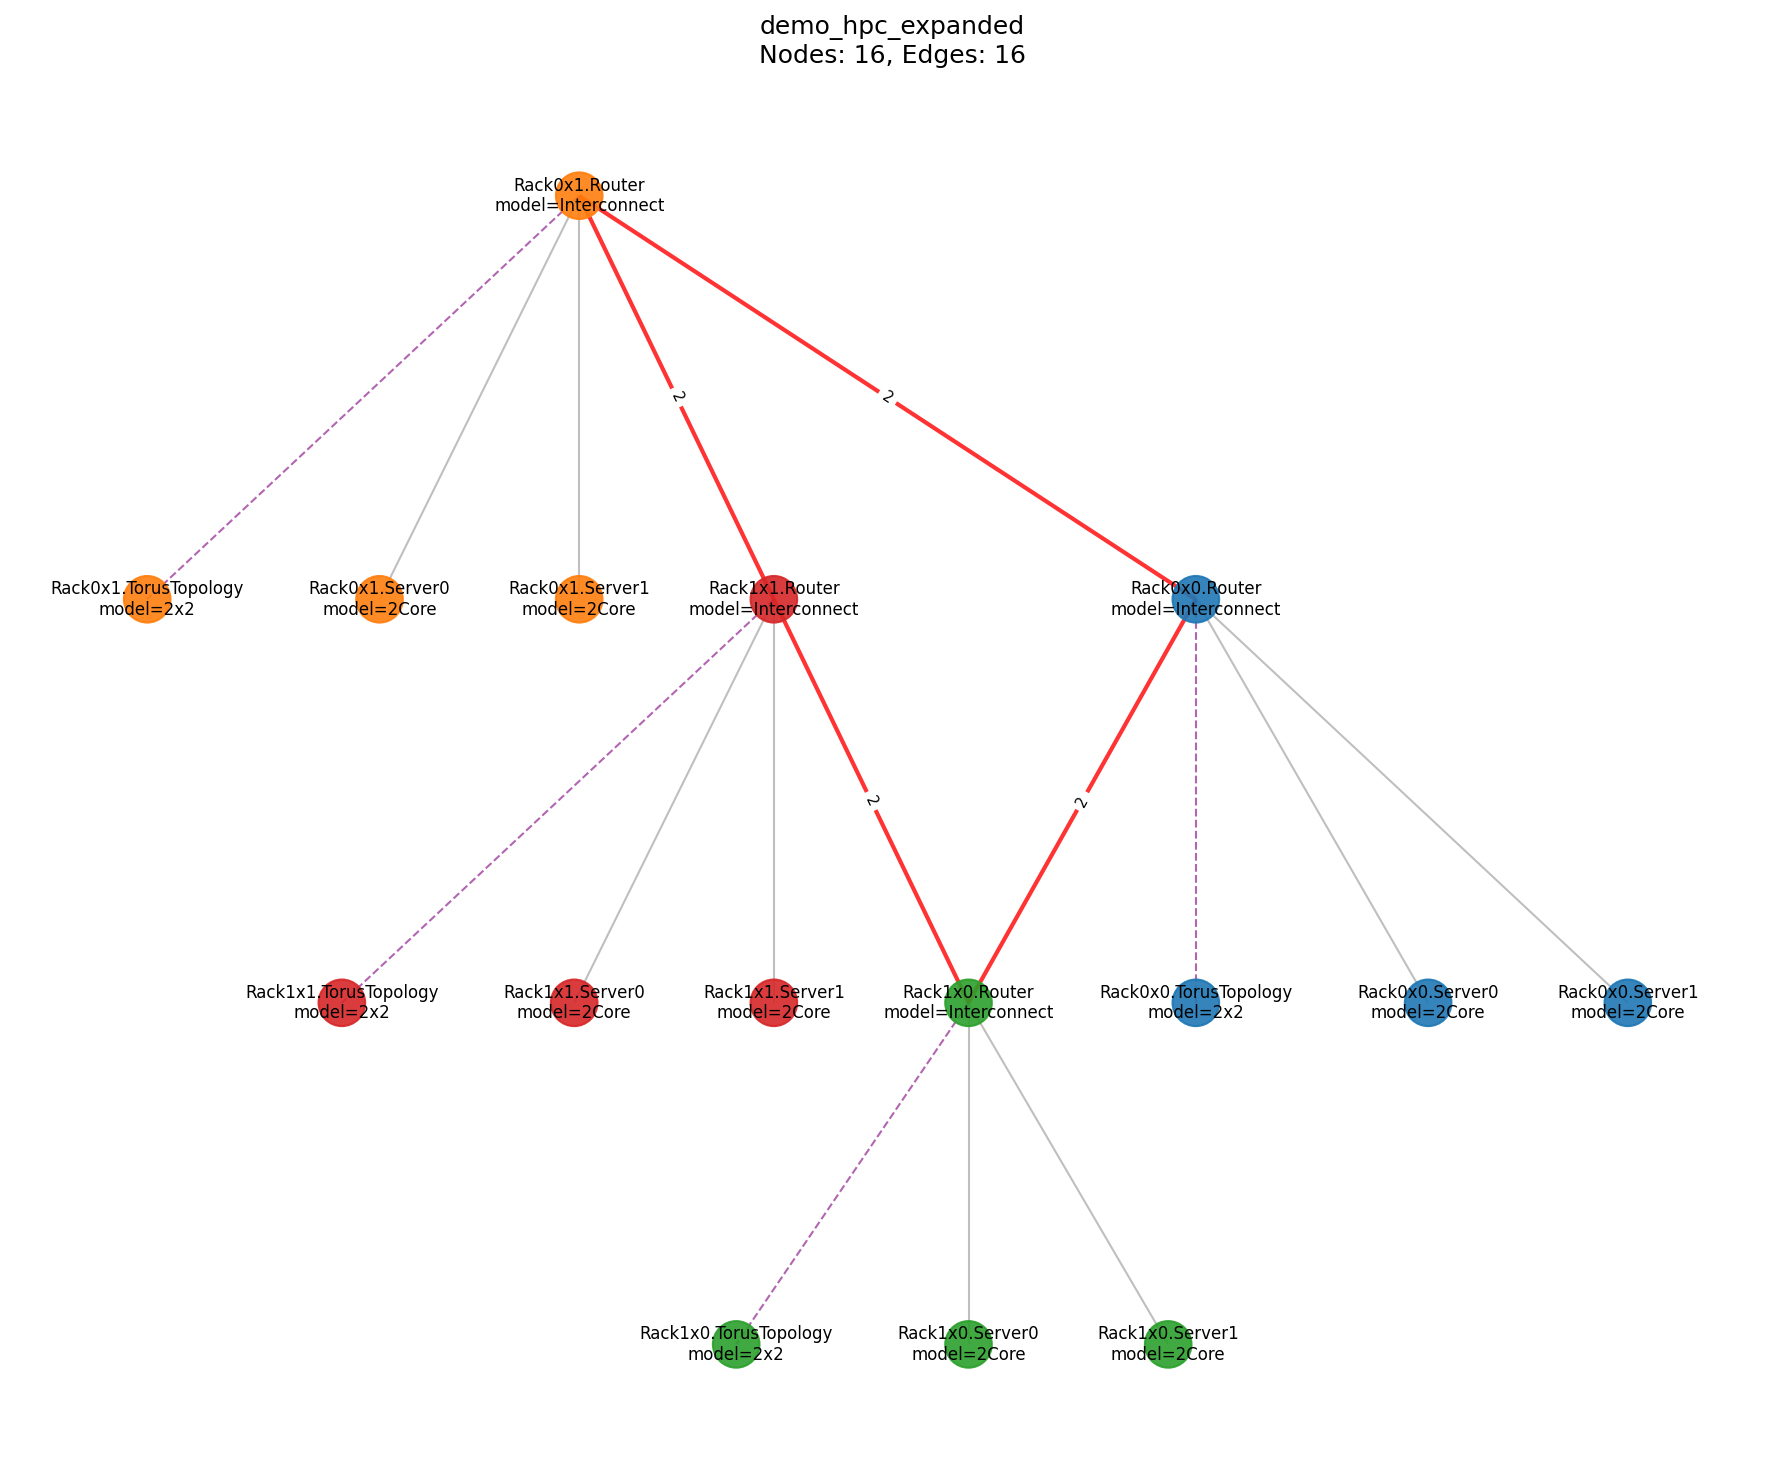

In [23]:
# One-level view: expand the Rack assemblies (into their Routers, Servers, and
# torus-topology submodules) but leave the Servers themselves as assemblies.
# We stop at one level because the Server assembly links directly to a
# submodule port, which the full-flatten path in ahp_graph does not support.
# Still no grid callbacks -- the automatic layout handles this non-grid graph.
if os.path.isdir(_hpc_dir):
    cluster_l1 = HPC.Cluster(shape='2x2', nodes=2, cores=2)
    cluster_l1.flatten(levels=1)
    print(f'HPC cluster (1 level expanded): {len(cluster_l1.devices)} '
          f'devices, {len(cluster_l1.links)} links')
    cluster_l1.write_networkx(
        'demo_hpc_expanded',
        output=OUTPUT_DIR,
        hierarchy=False,
        color_by_partition=True,
        highlight_inter_rank=True,
        full_labels=True,
    )
    show_image(f'{OUTPUT_DIR}/demo_hpc_expanded.png')
